In [35]:
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import matplotlib.dates as mdates
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing


df = pd.read_csv("harga_beras.csv", parse_dates=['tanggal'])

df = df[df['tanggal'] >= '2024-01-01']

df.head()

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
0,1,3501,2026-02-27,1,12483.0,2
1,2,3503,2026-02-27,1,13000.0,2
2,3,3504,2026-02-27,1,12790.0,2
3,4,3505,2026-02-27,1,12450.0,2
4,5,3507,2026-02-27,1,12750.0,2


# Function 

## Preprocessing

In [36]:
def get_start_last_date(df):
    df = df.copy()
    df['tanggal'] = pd.to_datetime(df['tanggal'])
    start_date = df['tanggal'].min()
    last_date = df['tanggal'].max()
    return start_date, last_date

def search_missing_value(df, week_end=False):
    df = df.copy()
    
    # pastikan datetime
    df['tanggal'] = pd.to_datetime(df['tanggal'])
    
    # jika weekend tidak dipakai
    if not week_end:
        df = df[df['tanggal'].dt.weekday < 5]
        freq = 'B'   # business day
    else:
        freq = 'D'   # semua hari

    # ambil range tanggal
    start_date, last_date = get_start_last_date(df)

    all_dates = pd.date_range(
        start=start_date,
        end=last_date,
        freq=freq
    )

    # tanggal yang ada
    existing_dates = pd.to_datetime(df['tanggal'].dt.normalize().unique())

    # cari missing date
    missing_dates = sorted(set(all_dates) - set(existing_dates))

    percentage_missing = round(len(missing_dates) / len(all_dates) * 100, 1)

    print(f"Jumlah data baris = {len(df)}")
    print("Jumlah missing:", len(missing_dates))
    print(f"Persentase missing: {percentage_missing}%")
    print("Date missing:", missing_dates)

    # isi tanggal yang hilang
    df = df.set_index('tanggal')
    df = df.reindex(all_dates)

    # isi kolom konstan
    df['kode_kab_kota'] = 1
    df['variant_id'] = 1
    df['tipe_harga_id'] = 1

    # kembalikan tanggal ke kolom
    df = df.reset_index().rename(columns={'index': 'tanggal'})

    # hapus kolom id jika ada
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    return df

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

def evaluate_imputation(df, price_col="harga", date_col="tanggal", missing_ratio=0.1, seed=42):

    np.random.seed(seed)

    df_test = df.copy()

    # buat missing artificial
    mask = np.random.rand(len(df_test)) < missing_ratio
    true_values = df_test.loc[mask, price_col]

    df_test.loc[mask, price_col] = np.nan

    # imputasi
    ffill = df_test[price_col].ffill()
    linear = df_test[price_col].interpolate()

    # dataframe evaluasi
    eval_df = pd.DataFrame({
        "true": true_values,
        "ffill": ffill[mask],
        "linear": linear[mask]
    })

    # hapus NaN
    eval_ffill = eval_df.dropna(subset=["true", "ffill"])
    eval_linear = eval_df.dropna(subset=["true", "linear"])

    # MAE
    mae_ffill = mean_absolute_error(eval_ffill["true"], eval_ffill["ffill"])
    mae_linear = mean_absolute_error(eval_linear["true"], eval_linear["linear"])

    # MAPE
    mape_ffill = mean_absolute_percentage_error(eval_ffill["true"], eval_ffill["ffill"]) * 100
    mape_linear = mean_absolute_percentage_error(eval_linear["true"], eval_linear["linear"]) * 100

    print("Forward Fill")
    print("MAE :", mae_ffill)
    print("MAPE:", mape_ffill)

    print("\nLinear Interpolation")
    print("MAE :", mae_linear)
    print("MAPE:", mape_linear)

    # pilih metode terbaik
    method = "linear" if mae_linear < mae_ffill else "ffill"
    print(f"\nMetode terbaik berdasarkan MAE: {method}")

    # imputasi pada data asli
    df = df.sort_values(date_col)
    df = df.set_index(date_col)

    if method == "linear":
        df[price_col] = df[price_col].interpolate(method="linear")
    else:
        df[price_col] = df[price_col].ffill()

    missing = df[price_col].isna().sum()
    print(f"Jumlah missing setelah imputasi = {missing}")

    return df, {
        "mae_ffill": mae_ffill,
        "mape_ffill": mape_ffill,
        "mae_linear": mae_linear,
        "mape_linear": mape_linear,
        "best_method": method
    }


## Uji Asumsi

In [37]:
# ─────────────────────────────────────────────
# KONFIGURASI
# ─────────────────────────────────────────────
KOLOM_TARGET  = "harga"
KOLOM_TANGGAL = "tanggal"
MAX_LAGS      = 24
ALPHA         = 0.05


# =====================================================================
# 1. ADF TEST
# =====================================================================
def uji_adf(series, label="Series"):
    print("\n" + "="*60)
    print(f"  1. ADF TEST — Stasioneritas: {label}")
    print("="*60)

    hasil = adfuller(series, autolag="AIC")
    stat, pval, lags_used, nobs = hasil[0], hasil[1], hasil[2], hasil[3]
    critical = hasil[4]

    print(f"  ADF Statistic : {stat:.4f}")
    print(f"  p-value       : {pval:.4f}")
    print(f"  Lags Used     : {lags_used}")
    print(f"  Observations  : {nobs}")
    print("  Critical Values:")
    for key, val in critical.items():
        print(f"    {key}: {val:.4f}")

    if pval < ALPHA:
        print(f"\n  ✅ STASIONER (p={pval:.4f} < {ALPHA}) → Tidak perlu differencing")
    else:
        print(f"\n  ❌ TIDAK STASIONER (p={pval:.4f} ≥ {ALPHA}) → Lakukan differencing (d≥1)")

    return pval < ALPHA


# =====================================================================
# 2. ACF & PACF
# =====================================================================
def plot_acf_pacf(series, label="Series", lags=MAX_LAGS):
    print("\n" + "="*60)
    print(f"  2. ACF & PACF — Parameter ARIMA (p, d, q): {label}")
    print("="*60)

    acf_vals  = acf(series, nlags=lags, fft=True)
    pacf_vals = pacf(series, nlags=lags)
    ci        = 1.96 / np.sqrt(len(series))

    q_kandidat = [i for i in range(1, lags+1) if abs(acf_vals[i])  > ci]
    p_kandidat = [i for i in range(1, lags+1) if abs(pacf_vals[i]) > ci]

    print(f"\n  Batas Signifikansi (±{ci:.4f})")
    print(f"  → ACF signifikan pada lag  : {q_kandidat[:5]}  → q kandidat")
    print(f"  → PACF signifikan pada lag : {p_kandidat[:5]}  → p kandidat")
    if q_kandidat: print(f"\n  Saran q (MA) : {q_kandidat[0]}")
    if p_kandidat: print(f"  Saran p (AR) : {p_kandidat[0]}")

    if not p_kandidat: print("  ⚠️  Tidak ada PACF signifikan → p kandidat default [1]"); p_kandidat = [1]
    if not q_kandidat: print("  ⚠️  Tidak ada ACF signifikan → q kandidat default [1]");  q_kandidat = [1]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    fig.suptitle(f"ACF & PACF — {label}", fontsize=14, fontweight="bold", y=1.01)

    plot_acf( series, lags=lags, ax=axes[0], alpha=ALPHA,
              title="ACF → tentukan q")
    plot_pacf(series, lags=lags, ax=axes[1], alpha=ALPHA,
              title="PACF → tentukan p", method="ywm")

    for ax in axes:
        ax.axhline(y= ci, linestyle="--", color="red", linewidth=0.8, alpha=0.7)
        ax.axhline(y=-ci, linestyle="--", color="red", linewidth=0.8, alpha=0.7)
        ax.set_xlabel("Lag")

    plt.tight_layout()
    plt.show()

    return p_kandidat, q_kandidat


# =====================================================================
# 3. LJUNG-BOX TEST
# =====================================================================
def uji_ljung_box(series, label="Series", lags=MAX_LAGS):
    print("\n" + "="*60)
    print(f"  3. LJUNG-BOX TEST — White Noise Residual: {label}")
    print("="*60)

    hasil_lb = acorr_ljungbox(series, lags=list(range(1, lags+1)), return_df=True)
    lb_stat  = hasil_lb["lb_stat"].iloc[-1]
    lb_pval  = hasil_lb["lb_pvalue"].iloc[-1]

    print(f"\n  Lag diuji  : {lags}")
    print(f"  LB Stat    : {lb_stat:.4f}")
    print(f"  LB p-value : {lb_pval:.4f}")

    if lb_pval > ALPHA:
        print(f"\n  ✅ White Noise (p={lb_pval:.4f} ≥ {ALPHA}) — Model adequate")
    else:
        print(f"\n  ❌ Autokorelasi (p={lb_pval:.4f} < {ALPHA}) — Perlu perbaikan model")

    return hasil_lb


# =====================================================================
# 4. ARCH TEST
# =====================================================================
def uji_arch(series, label="Series", lags=12):
    print("\n" + "="*60)
    print(f"  4. ARCH TEST — Heteroskedastisitas & Volatilitas: {label}")
    print("="*60)

    ret = series.pct_change().dropna()

    from statsmodels.stats.diagnostic import het_arch
    stat, pval, _, _ = het_arch(ret, nlags=lags)

    print(f"\n  ARCH LM Statistic : {stat:.4f}")
    print(f"  p-value           : {pval:.4f}")
    print(f"  Lags Diuji        : {lags}")

    if pval < ALPHA:
        print(f"\n  ❌ EFEK ARCH ADA (p={pval:.4f} < {ALPHA}) → Gunakan GARCH")
    else:
        print(f"\n  ✅ TIDAK ADA efek ARCH (p={pval:.4f} ≥ {ALPHA}) → ARIMA cukup")

    vol_fit  = arch_model(ret, vol="Garch", p=1, q=1, rescale=True).fit(disp="off")
    cond_vol = vol_fit.conditional_volatility

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"ARCH Test — Return & Conditional Volatility: {label}",
                 fontsize=13, fontweight="bold")

    axes[0].plot(ret.index, ret.values, color="#2563eb", linewidth=0.8, alpha=0.85)
    axes[0].set_title(f"Return {label}")
    axes[0].set_ylabel("Return")
    axes[0].axhline(0, color="gray", linewidth=0.5)

    axes[1].plot(cond_vol.index, cond_vol.values, color="#dc2626", linewidth=1.2)
    axes[1].set_title(f"Conditional Volatility (GARCH(1,1)) — {label}")
    axes[1].set_ylabel("Volatilitas")
    axes[1].set_xlabel("Tanggal")

    plt.tight_layout()
    plt.show()

    return stat, pval


# =====================================================================
# RINGKASAN HASIL
# =====================================================================
def cetak_ringkasan(stasioner, lb_df, arch_pval, label="Series"):
    print("\n" + "="*60)
    print(f"  RINGKASAN HASIL UJI STATISTIK — {label}")
    print("="*60)

    n_lb_sig = (lb_df["lb_pvalue"] < ALPHA).sum()

    status = {
        "ADF (Stasioneritas)"    : "✅ Stasioner" if stasioner else "❌ Tidak Stasioner → differencing",
        "ACF/PACF (ARIMA)"       : "✅ Lihat plot untuk p & q",
        "Ljung-Box (White Noise)": f"{'✅ White Noise' if n_lb_sig == 0 else f'❌ {n_lb_sig} lag signifikan'}",
        "ARCH (Volatilitas)"     : f"{'❌ Ada efek ARCH → GARCH' if arch_pval < ALPHA else '✅ Tidak ada efek ARCH'}",
    }

    for uji, hasil in status.items():
        print(f"  {'['+uji+']':<30} {hasil}")

    print("\n  Rekomendasi:")
    if not stasioner:   print("  • Lakukan first-differencing (d=1) sebelum ARIMA")
    if n_lb_sig > 0:    print("  • Sesuaikan parameter p, q berdasarkan ACF/PACF")
    if arch_pval < ALPHA: print("  • Pertimbangkan model GARCH(1,1) untuk volatilitas")
    print("="*60)


# =====================================================================
# FUNGSI UTAMA — jalankan semua uji untuk 1 dataframe
# =====================================================================
def jalankan_uji(df, label, kolom_target=KOLOM_TARGET, kolom_tanggal=KOLOM_TANGGAL):
    print("\n" + "█"*60)
    print(f"  ANALISIS STATISTIK — {label}")
    print("█"*60)

    # Siapkan series
    if kolom_tanggal and kolom_tanggal in df.columns:
        df = df.set_index(kolom_tanggal)
    series = df[kolom_target].dropna()

    stasioner               = uji_adf(series, label=label)
    p_kandidat, q_kandidat  = plot_acf_pacf(series, label=label)
    lb_df                   = uji_ljung_box(series, label=label)
    arch_stat, arch_pval    = uji_arch(series, label=label)
    cetak_ringkasan(stasioner, lb_df, arch_pval, label=label)

    return series, p_kandidat, q_kandidat

## Modeling

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from itertools import product
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ─────────────────────────────────────────────
# KONFIGURASI
# ─────────────────────────────────────────────
KOLOM_TARGET  = "harga"
KOLOM_TANGGAL = "tanggal"
ALPHA         = 0.05
TEST_SIZE     = None


# ─────────────────────────────────────────────
# HELPER METRICS
# ─────────────────────────────────────────────
def hitung_metrik(aktual, prediksi, label="Model"):
    aktual   = np.array(aktual)
    prediksi = np.array(prediksi)
    rmse = np.sqrt(mean_squared_error(aktual, prediksi))
    mae  = mean_absolute_error(aktual, prediksi)
    mape = np.mean(np.abs((aktual - prediksi) / aktual)) * 100
    print(f"\n  {'─'*42}")
    print(f"  📊 {label}")
    print(f"  {'─'*42}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  MAPE : {mape:.4f}%")
    return {"model": label, "RMSE": rmse, "MAE": mae, "MAPE": mape}


# ─────────────────────────────────────────────
# HELPER — Pilih Best Model
# Primary  : MAE terkecil
# Tiebreak : MAPE terkecil
# ─────────────────────────────────────────────
def pilih_best_model(metrik_list):
    sorted_list = sorted(metrik_list, key=lambda x: (x["MAE"], x["MAPE"]))
    return sorted_list[0]["model"]


# =====================================================================
# CEK STASIONERITAS & AUTO-DIFFERENCING
# =====================================================================
def cek_dan_differencing(df, label,
                          kolom_target=KOLOM_TARGET,
                          kolom_tanggal=KOLOM_TANGGAL,
                          max_diff=2):
    _df = df.copy()
    if kolom_tanggal and kolom_tanggal in _df.columns:
        _df = _df.set_index(kolom_tanggal)
    series = _df[kolom_target].dropna()

    print("\n" + "="*60)
    print(f"  CEK STASIONERITAS & DIFFERENCING — {label}")
    print("="*60)

    d       = 0
    current = series.copy()

    while d <= max_diff:
        stat, pval, _, _, _, _ = adfuller(current, autolag="AIC")
        print(f"\n  d={d} | ADF Stat: {stat:.4f} | p-value: {pval:.4f}", end="  ")

        if pval < ALPHA:
            print("✅ Stasioner")
            break
        else:
            print("❌ Tidak Stasioner")
            if d < max_diff:
                print(f"  → Melakukan differencing d={d+1}...")
                current = current.diff().dropna()
                d += 1
            else:
                print(f"  ⚠️ Sudah mencapai max differencing (d={max_diff}), lanjut dengan d={d}")
                break

    print(f"\n  Differencing order : d = {d}")
    print("="*60)

    return series, d


# =====================================================================
# MODEL 1 — ARIMA + GARCH(1,1)
# Hyperparameter tuning: MAE in-sample
# =====================================================================
def fit_arima_garch(train, test, d=0, exog_train=None, exog_test=None,
                    p_kandidat=None, q_kandidat=None):
    from statsmodels.stats.diagnostic import het_arch
    from arch import arch_model

    print("\n" + "="*60)
    model_name = "ARIMAX" if exog_train is not None else "ARIMA"
    _p_grid = sorted(set(p for p in p_kandidat if p <= 9)) if p_kandidat else list(range(5))
    _q_grid = sorted(set(q for q in q_kandidat if q <= 9)) if q_kandidat else list(range(5))
    # Selalu sertakan 0 agar model AR-only / MA-only juga diuji
    print(f"  MODEL 1 — {model_name}+GARCH (Grid Search, d={d})")
    print(f"  p kandidat (PACF) : {_p_grid}")
    print(f"  q kandidat (ACF)  : {_q_grid}")
    print(f"  Hyperparameter tuning : MAE in-sample (bukan AIC)")
    if exog_train is not None:
        n_exog = exog_train.shape[1] if hasattr(exog_train, "shape") and exog_train.ndim > 1 else 1
        print(f"  Exogenous variables  : {n_exog} variabel")
    print("="*60)

    _all_combos  = list(product(_p_grid, _q_grid))
    _zero_combos = []
    _rest_combos = _all_combos
    MAX_COMBOS = 150
    if len(_all_combos) > MAX_COMBOS:
        import random as _random; _rnd = _random.Random(42)
        _max_rest = max(0, MAX_COMBOS - len(_zero_combos))
        _rest_combos = _rnd.sample(_rest_combos, min(len(_rest_combos), _max_rest))
    _combos = _zero_combos + _rest_combos
    print(f"  Menguji {len(_combos)} kombinasi {model_name}...\n")

    hasil = []
    print(f"  {{'Model':<20}} {{'AIC':>10}} {{'BIC':>10}} {{'MAE_in':>10}}")
    print("  " + "-"*54)

    for p, q in _combos:
        try:
            m      = ARIMA(train, order=(p, d, q), exog=exog_train).fit()
            fitted = m.fittedvalues.dropna()
            actual = train.loc[fitted.index]
            mae_in = mean_absolute_error(actual, fitted)
            lbl    = f"ARIMA({p},{d},{q})"
            print(f"  {lbl:<20} {m.aic:>10.2f} {m.bic:>10.2f} {mae_in:>10.4f}")
            hasil.append({
                "order": (p, d, q),
                "AIC": m.aic, "BIC": m.bic,
                "MAE": mae_in, "fit": m
            })
        except Exception:
            pass

    df_h        = pd.DataFrame(hasil).sort_values(["MAE", "AIC"]).reset_index(drop=True)
    best        = df_h.iloc[0]
    arima_fit   = best["fit"]
    arima_order = best["order"]

    print(f"\n  🏆 Best ARIMA → {arima_order}")
    print(f"     MAE_in={best['MAE']:.4f} | AIC={best['AIC']:.2f} | BIC={best['BIC']:.2f}")

    residuals = arima_fit.resid.dropna()
    stat, pval, _, _ = het_arch(residuals, nlags=12)
    print(f"\n  ARCH Test pada residual ARIMA:")
    print(f"  LM Stat  : {stat:.4f}")
    print(f"  p-value  : {pval:.4f}")

    arima_fc = arima_fit.forecast(steps=TEST_SIZE, exog=exog_test)

    if pval >= 0.05:
        print(f"  ✅ Tidak ada efek ARCH → GARCH tidak diperlukan")
        lbl_prefix = "ARIMAX" if exog_train is not None else "ARIMA"
        metrik = hitung_metrik(test.values, arima_fc.values,
                               label=f"{lbl_prefix}{arima_order} (tanpa GARCH)")
        return arima_fc.values, metrik, arima_order, None, None

    print(f"  ❌ Ada efek ARCH → Lanjut fit GARCH(1,1)")

    garch     = arch_model(residuals, vol="Garch", p=1, q=1, dist="normal")
    garch_fit = garch.fit(disp="off")

    print(f"\n  GARCH(1,1) Results:")
    print(f"  AIC   : {garch_fit.aic:.2f}")
    print(f"  BIC   : {garch_fit.bic:.2f}")
    print(f"  omega : {garch_fit.params['omega']:.6f}")
    print(f"  alpha : {garch_fit.params['alpha[1]']:.4f}")
    print(f"  beta  : {garch_fit.params['beta[1]']:.4f}")

    garch_fc = garch_fit.forecast(horizon=TEST_SIZE, reindex=False)
    vol_fc   = np.sqrt(garch_fc.variance.values[-1])
    fc_vals  = arima_fc.values
    lower    = fc_vals - 1.96 * vol_fc
    upper    = fc_vals + 1.96 * vol_fc

    print(f"\n  Confidence Interval 95%:")
    print(f"  {'t':<5} {'Forecast':>12} {'Lower':>12} {'Upper':>12} {'Aktual':>12}")
    print("  " + "-"*56)
    for i in range(len(test)):
        print(f"  {i+1:<5} {fc_vals[i]:>12.2f} {lower[i]:>12.2f} {upper[i]:>12.2f} {test.values[i]:>12.2f}")

    lbl_prefix = "ARIMAX" if exog_train is not None else "ARIMA"
    metrik = hitung_metrik(test.values, fc_vals,
                           label=f"{lbl_prefix}{arima_order}+GARCH(1,1)")

    return fc_vals, metrik, arima_order, lower, upper


# =====================================================================
# MODEL 2 — SARIMAX + GARCH(1,1)
# Hyperparameter tuning: MAE in-sample
# =====================================================================
def fit_sarimax_garch(train, test, d=0, seasonal_period=7,
                      exog_train=None, exog_test=None,
                      p_kandidat=None, q_kandidat=None):
    from statsmodels.stats.diagnostic import het_arch
    from arch import arch_model

    _model_base = "SARIMAX" if exog_train is not None else "SARIMA"
    print("\n" + "="*60)
    _p_grid = sorted(set(p for p in p_kandidat if p <= 9)) if p_kandidat else [1, 2, 3]
    _q_grid = sorted(set(q for q in q_kandidat if q <= 9)) if q_kandidat else [1, 2, 3]
    print(f"  MODEL 2 — {_model_base}+GARCH (Grid Search, d={d}, m={seasonal_period})")
    print(f"  p kandidat (PACF) : {_p_grid}")
    print(f"  q kandidat (ACF)  : {_q_grid}")
    print(f"  Hyperparameter tuning : MAE in-sample (bukan AIC)")
    if exog_train is not None:
        n_exog = exog_train.shape[1] if hasattr(exog_train, "shape") and exog_train.ndim > 1 else 1
        print(f"  Exogenous variables: {n_exog} variabel")
    else:
        print(f"  Exogenous variables: tidak ada (mode {_model_base} murni)")
    print("="*60)

    P_vals = [0, 1]
    Q_vals = [0, 1]
    D      = 0

    _all_pq  = list(product(_p_grid, _q_grid))
    _zero_pq = []
    _rest_pq = _all_pq
    _max_seasonal = max(1, 150 // (len(P_vals) * len(Q_vals)))
    if len(_all_pq) > _max_seasonal:
        import random as _random; _rnd = _random.Random(42)
        _max_rest = max(0, _max_seasonal - len(_zero_pq))
        _rest_pq = _rnd.sample(_rest_pq, min(len(_rest_pq), _max_rest))
    _pq_combos = _zero_pq + _rest_pq

    hasil = []
    print(f"  Menguji {len(_pq_combos) * len(P_vals) * len(Q_vals)} kombinasi {_model_base}...\n")
    print(f"  {{'Model':<38}} {{'AIC':>10}} {{'MAE_in':>10}}")
    print("  " + "-"*62)

    for p, q in _pq_combos:
      for P, Q in product(P_vals, Q_vals):
          try:
              m = SARIMAX(
                  train,
                  exog=exog_train,
                  order=(p, d, q),
                  seasonal_order=(P, D, Q, seasonal_period),
                  enforce_stationarity=False,
                  enforce_invertibility=False
              ).fit(disp=False)
              fitted = m.fittedvalues.dropna()
              actual = train.loc[fitted.index]
              mae_in = mean_absolute_error(actual, fitted)
              lbl    = f"{_model_base}({p},{d},{q})({P},{D},{Q},{seasonal_period})"
              print(f"  {lbl:<38} {m.aic:>10.2f} {mae_in:>10.4f}")
              hasil.append({
                  "order": (p, d, q),
                  "seasonal": (P, D, Q, seasonal_period),
                  "AIC": m.aic, "BIC": m.bic,
                  "MAE": mae_in, "fit": m
              })
          except Exception:
              pass

    df_h        = pd.DataFrame(hasil).sort_values(["MAE", "AIC"]).reset_index(drop=True)
    best        = df_h.iloc[0]
    sarimax_fit = best["fit"]
    sx_order    = best["order"]
    sx_seasonal = best["seasonal"]

    print(f"\n  🏆 Best {_model_base} → order={sx_order} seasonal={sx_seasonal}")
    print(f"     MAE_in={best['MAE']:.4f} | AIC={best['AIC']:.2f} | BIC={best['BIC']:.2f}")

    residuals = sarimax_fit.resid.dropna()
    stat, pval, _, _ = het_arch(residuals, nlags=12)
    print(f"\n  ARCH Test pada residual {_model_base}:")
    print(f"  LM Stat  : {stat:.4f}")
    print(f"  p-value  : {pval:.4f}")

    sarimax_fc = sarimax_fit.forecast(steps=TEST_SIZE, exog=exog_test)

    if pval >= 0.05:
        print(f"  ✅ Tidak ada efek ARCH → GARCH tidak diperlukan")
        metrik = hitung_metrik(test.values, sarimax_fc.values,
                               label=f"{_model_base}{sx_order}{sx_seasonal} (tanpa GARCH)")
        return sarimax_fc.values, metrik, sx_order, sx_seasonal, None, None

    print(f"  ❌ Ada efek ARCH → Lanjut fit GARCH(1,1)")

    garch     = arch_model(residuals, vol="Garch", p=1, q=1, dist="normal")
    garch_fit = garch.fit(disp="off")

    print(f"\n  GARCH(1,1) Results:")
    print(f"  AIC   : {garch_fit.aic:.2f}")
    print(f"  BIC   : {garch_fit.bic:.2f}")
    print(f"  omega : {garch_fit.params['omega']:.6f}")
    print(f"  alpha : {garch_fit.params['alpha[1]']:.4f}")
    print(f"  beta  : {garch_fit.params['beta[1]']:.4f}")

    garch_fc = garch_fit.forecast(horizon=TEST_SIZE, reindex=False)
    vol_fc   = np.sqrt(garch_fc.variance.values[-1])
    fc_vals  = sarimax_fc.values
    lower    = fc_vals - 1.96 * vol_fc
    upper    = fc_vals + 1.96 * vol_fc

    print(f"\n  Confidence Interval 95%:")
    print(f"  {'t':<5} {'Forecast':>12} {'Lower':>12} {'Upper':>12} {'Aktual':>12}")
    print("  " + "-"*56)
    for i in range(len(test)):
        print(f"  {i+1:<5} {fc_vals[i]:>12.2f} {lower[i]:>12.2f} {upper[i]:>12.2f} {test.values[i]:>12.2f}")

    metrik = hitung_metrik(test.values, fc_vals,
                           label=f"{_model_base}{sx_order}{sx_seasonal}+GARCH(1,1)")

    return fc_vals, metrik, sx_order, sx_seasonal, lower, upper


# =====================================================================
# MODEL 3 — HOLT-WINTERS
# Hyperparameter tuning: MAE in-sample (bukan AIC)
# =====================================================================
def fit_holt_winters(train, test, seasonal_period=7):
    print("\n" + "="*60)
    print("  MODEL 3 — HOLT-WINTERS EXPONENTIAL SMOOTHING")
    print("  Hyperparameter tuning : MAE in-sample (bukan AIC)")
    print("="*60)

    configs = [
        {"trend": "add", "seasonal": "add",  "label": "HW Additive"},
        {"trend": "add", "seasonal": "mul",  "label": "HW Multiplicative"},
        {"trend": "add", "seasonal": None,   "label": "HW No Seasonal"},
        {"trend": "mul", "seasonal": "add",  "label": "HW Mul-Trend+Add-Seasonal"},
    ]

    hasil_hw = []
    print(f"\n  {'Konfigurasi':<35} {'SSE':>14} {'AIC':>10} {'MAE_in':>10}")
    print("  " + "-"*74)

    for cfg in configs:
        try:
            m = ExponentialSmoothing(
                train,
                trend=cfg["trend"],
                seasonal=cfg["seasonal"],
                seasonal_periods=seasonal_period if cfg["seasonal"] else None,
                damped_trend=False
            ).fit(optimized=True)
            fitted = m.fittedvalues.dropna()
            actual = train.loc[fitted.index]
            mae_in = mean_absolute_error(actual, fitted)
            print(f"  {cfg['label']:<35} {m.sse:>14.2f} {m.aic:>10.2f} {mae_in:>10.4f}")
            hasil_hw.append({**cfg, "sse": m.sse, "aic": m.aic, "mae_in": mae_in, "fit": m})
        except Exception:
            print(f"  {cfg['label']:<35} {'GAGAL':>14}")

    best_hw     = sorted(hasil_hw, key=lambda x: (x["mae_in"], x["aic"]))[0]
    best_hw_fit = best_hw["fit"]
    print(f"\n  🏆 Best Holt-Winters → {best_hw['label']}")
    print(f"     MAE_in={best_hw['mae_in']:.4f} | AIC={best_hw['aic']:.2f}")

    fc_hw  = best_hw_fit.forecast(TEST_SIZE)
    metrik = hitung_metrik(test.values, fc_hw.values, label=best_hw["label"])

    return fc_hw, metrik, best_hw["label"]


# =====================================================================
# MODEL 4 — FUZZY TIME SERIES (Chen 1996)
# Hyperparameter tuning: n_intervals dipilih berdasarkan MAE in-sample
# =====================================================================
def fit_prophet_seasonal(train, test, seasonal_period=None):
    """
    Prophet dengan komponen musiman aktif (yearly + weekly + opsional custom).

    Parameters
    ----------
    train           : pd.Series dengan DatetimeIndex
    test            : pd.Series dengan DatetimeIndex
    seasonal_period : int | None — periode custom seasonality (misal 52 untuk
                      data mingguan, 7 untuk harian). Jika None, tidak
                      ditambahkan custom seasonality.

    Grid search internal (hardcoded):
      changepoint_prior_scale  : [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
      seasonality_prior_scale  : [0.01, 0.1, 1.0, 10.0]
      seasonality_mode         : ["additive", "multiplicative"]
      fourier_order (custom)   : [3, 5, 10]  — hanya jika seasonal_period != None
    Kriteria terbaik : MAE in-sample terkecil
    """
    try:
        from prophet import Prophet
    except ImportError:
        raise ImportError(
            "Package 'prophet' belum terinstall. "
            "Jalankan: pip install prophet"
        )

    # ── Grid search hardcoded ──────────────────────────────────────────
    CPS_GRID    = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
    SPS_GRID    = [0.01, 0.1, 1.0, 10.0]
    MODE_GRID   = ["additive", "multiplicative"]
    FOURIER_GRID = [3, 5, 10]   # hanya dipakai jika seasonal_period diberikan
    MAX_COMBOS  = 150

    print("\n" + "="*60)
    print("  MODEL 6 — PROPHET SEASONAL")
    print("  Komponen musiman aktif (yearly + weekly)")
    if seasonal_period:
        print(f"  Custom seasonality   : period={seasonal_period}, fourier_order={FOURIER_GRID}")
    print("  Hyperparameter tuning : MAE in-sample")
    print(f"  changepoint_prior_scale  : {CPS_GRID}")
    print(f"  seasonality_prior_scale  : {SPS_GRID}")
    print(f"  seasonality_mode         : {MODE_GRID}")
    print("="*60)

    # ── Siapkan DataFrame Prophet ──────────────────────────────────────
    df_train = pd.DataFrame({
        "ds": train.index,
        "y":  train.values
    }).reset_index(drop=True)

    # ── Grid search: CPS × SPS × mode (× fourier jika ada custom period) ─
    hasil_gs = []
    fourier_candidates = FOURIER_GRID if seasonal_period else [None]
    import random as _rnd
    _all_combos = list(product(CPS_GRID, SPS_GRID, MODE_GRID, fourier_candidates))
    if len(_all_combos) > MAX_COMBOS:
        _rnd.seed(42)
        _all_combos = _rnd.sample(_all_combos, MAX_COMBOS)
    total = len(_all_combos)
    print(f"\n  Menguji {total} kombinasi hyperparameter...\n")

    if seasonal_period:
        print(f"  {'CPS':<8} {'SPS':<8} {'Mode':<16} {'Fourier':<8} {'MAE_in':>12}")
        print("  " + "-"*58)
    else:
        print(f"  {'CPS':<8} {'SPS':<8} {'Mode':<16} {'MAE_in':>12}")
        print("  " + "-"*48)

    for cps, sps, mode, fourier in _all_combos:
        try:
            m = Prophet(
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode=mode,
            )
            if seasonal_period and fourier:
                m.add_seasonality(
                    name=f"custom_period_{seasonal_period}",
                    period=seasonal_period,
                    fourier_order=fourier
                )
            m.fit(df_train)
            fitted_df = m.predict(df_train[["ds"]])
            mae_in    = mean_absolute_error(df_train["y"].values,
                                            fitted_df["yhat"].values)
            if seasonal_period:
                print(f"  {cps:<8} {sps:<8} {mode:<16} {fourier:<8} {mae_in:>12.4f}")
            else:
                print(f"  {cps:<8} {sps:<8} {mode:<16} {mae_in:>12.4f}")
            hasil_gs.append({
                "cps": cps, "sps": sps, "mode": mode,
                "fourier": fourier, "mae_in": mae_in
            })
        except Exception as e:
            print(f"  {'GAGAL':<8} ({e})")

    best_gs   = sorted(hasil_gs, key=lambda x: x["mae_in"])[0]
    best_cps  = best_gs["cps"]
    best_sps  = best_gs["sps"]
    best_mode = best_gs["mode"]
    best_fou  = best_gs["fourier"]
    print(f"\n  🏆 Best hyperparameter → CPS={best_cps}, SPS={best_sps}, mode={best_mode}", end="")
    if seasonal_period:
        print(f", fourier={best_fou}")
    else:
        print()
    print(f"     MAE_in={best_gs['mae_in']:.4f}")

    # ── Fit ulang dengan hyperparameter terbaik ────────────────────────
    model_best = Prophet(
        changepoint_prior_scale=best_cps,
        seasonality_prior_scale=best_sps,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode=best_mode,
    )
    if seasonal_period and best_fou:
        model_best.add_seasonality(
            name=f"custom_period_{seasonal_period}",
            period=seasonal_period,
            fourier_order=best_fou
        )
    model_best.fit(df_train)

    # ── Forecast pada periode test ─────────────────────────────────────
    df_test_future = pd.DataFrame({"ds": test.index})
    forecast       = model_best.predict(df_test_future)

    fc_vals = forecast["yhat"].values
    lower   = forecast["yhat_lower"].values
    upper   = forecast["yhat_upper"].values

    # ── Print komponen Prophet ─────────────────────────────────────────
    print(f"\n  Komponen yang dimodelkan Prophet:")
    komponen = ["trend", "yearly", "weekly"]
    if seasonal_period:
        komponen.append(f"custom_period_{seasonal_period}")
    for k in komponen:
        if k in forecast.columns:
            print(f"  • {k:<30} mean={forecast[k].mean():.4f}  std={forecast[k].std():.4f}")

    print(f"\n  Confidence Interval 95% (Prophet uncertainty interval):")
    print(f"  {'t':<5} {'Forecast':>12} {'Lower':>12} {'Upper':>12} {'Aktual':>12}")
    print("  " + "-"*56)
    for i in range(len(test)):
        print(f"  {i+1:<5} {fc_vals[i]:>12.2f} {lower[i]:>12.2f} {upper[i]:>12.2f} {test.values[i]:>12.2f}")

    sp_info = f", period={seasonal_period}, fourier={best_fou}" if seasonal_period else ""
    label   = f"Prophet Seasonal ({best_mode}, CPS={best_cps}{sp_info})"
    metrik  = hitung_metrik(test.values, fc_vals, label=label)

    return fc_vals, metrik, lower, upper, model_best

# =====================================================================
# PLOT PERBANDINGAN
# =====================================================================
def plot_perbandingan(train, test, forecasts: dict, metrik_list: list,
                      ci_bands: dict = None, label: str = ""):

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib.ticker import FuncFormatter

    PALETTE = [
        ("#dc2626", "-",   1.8),   # ARIMA+GARCH
        ("#7c3aed", "--",  1.8),   # SARIMAX+GARCH
        ("#16a34a", "-.",  1.8),   # HW
        ("#f59e0b", ":",   2.2),   # Fuzzy TS
        ("#0891b2", "-",   1.8),   # Prophet Non-Seasonal
        ("#db2777", "--",  1.8),   # Prophet Seasonal
    ]

    fig, ax = plt.subplots(figsize=(16, 5))

    # ===============================================================
    # PLOT DATA TRAIN
    # ===============================================================
    train_vis = train[train.index >= "2024-01-01"]

    ax.plot(train_vis.index, train_vis.values,
            color="#1e40af", linewidth=1.2,
            label="Train (2024–2025)", zorder=2)

    # ===============================================================
    # PLOT DATA AKTUAL
    # ===============================================================
    ax.plot(test.index, test.values,
            color="#111827", linewidth=2.2,
            label="Aktual 2026", zorder=5)

    # ===============================================================
    # PLOT FORECAST
    # ===============================================================
    for i, (name, fc_vals) in enumerate(forecasts.items()):

        color, ls, lw = PALETTE[i % len(PALETTE)]

        ax.plot(test.index, fc_vals,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=name,
                zorder=4)

        # Confidence interval
        if ci_bands and name in ci_bands:
            lower, upper = ci_bands[name]

            if lower is not None and upper is not None:
                ax.fill_between(
                    test.index,
                    lower,
                    upper,
                    alpha=0.12,
                    color=color,
                    label=f"CI 95% {name}"
                )

    # ===============================================================
    # GARIS PEMBATAS TRAIN / TEST
    # ===============================================================
    ax.axvline(
        x=test.index[0],
        color="gray",
        linewidth=1.0,
        linestyle="--",
        alpha=0.6,
        label="Batas Train | Test"
    )

    # ===============================================================
    # AUTO SCALE Y-AXIS (AGAR TIDAK DIMULAI DARI 0)
    # ===============================================================
    all_values = []

    all_values.extend(train_vis.values)
    all_values.extend(test.values)

    for fc in forecasts.values():
        all_values.extend(fc)

    all_values = np.array(all_values)

    ymin = np.percentile(all_values, 1)
    ymax = np.percentile(all_values, 99)

    margin = (ymax - ymin) * 0.08

    ax.set_ylim(ymin - margin, ymax + margin)

    # ===============================================================
    # FORMAT AXIS
    # ===============================================================
    ax.set_title(
        f"Perbandingan Model Forecast — {label} (2024–2026)",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Waktu")
    ax.set_ylabel("Harga (Rp)")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.xticks(rotation=30)

    # format ribuan
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)

    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    # ===============================================================
    # TABEL PERBANDINGAN MODEL
    # ===============================================================
    best_model = pilih_best_model(metrik_list)

    min_mae = min(m["MAE"] for m in metrik_list)
    mae_tied = [m for m in metrik_list if m["MAE"] == min_mae]

    print("\n" + "="*68)
    print(f"  TABEL PERBANDINGAN MODEL — {label} — Test 2026")
    print(f"  Kriteria pemilihan best model : MAE terkecil")
    print("="*68)

    print(f"  {'No':<4} {'Model':<42} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
    print("  " + "-"*72)

    for idx, m in enumerate(metrik_list, 1):

        flag = " 🏆" if m["model"] == best_model else ""

        print(
            f"  {idx:<4} "
            f"{m['model']:<42} "
            f"{m['RMSE']:>8.3f} "
            f"{m['MAE']:>8.3f} "
            f"{m['MAPE']:>7.4f}%{flag}"
        )

    print(f"\n  🏆 Best Model → {best_model}")

    if len(mae_tied) > 1:
        print(
            f"  ℹ️  MAE sama pada {len(mae_tied)} model "
            f"→ dipilih berdasarkan MAPE terkecil"
        )

    print("="*68)


# =====================================================================
# FUNGSI UTAMA MODELING
# =====================================================================
def jalankan_modeling(df, label,
                      kolom_target=KOLOM_TARGET,
                      kolom_tanggal=KOLOM_TANGGAL,
                      seasonal_period=12,
                      exog_train=None,
                      exog_test=None,
                      exog_source_df=None,
                      d_order=0,
                      p_kandidat=None,
                      q_kandidat=None,
                      # ── Parameter konversi mingguan ──────────────
                      ke_mingguan:      bool = False,
                      week_start:       str  = "Mon",
                      aggfunc:          str  = "mean",
                      min_obs:          int  = 1,
                      include_weekend:  bool = True,
                      ):
    """
    Parameters
    ----------
    df              : DataFrame dengan kolom tanggal dan harga
    label           : Nama komoditas / label untuk print & plot
    kolom_target    : Nama kolom harga (default: 'harga')
    kolom_tanggal   : Nama kolom tanggal (default: 'tanggal')
    seasonal_period : Periode musiman (12=bulanan, 52=mingguan, 7=harian)
                      Digunakan juga sebagai custom seasonality Prophet Seasonal.
    exog_train      : Variabel eksogen train (opsional, untuk ARIMAX/SARIMAX)
    exog_test       : Variabel eksogen test  (opsional, untuk ARIMAX/SARIMAX)
    exog_source_df  : DataFrame atau list of DataFrame harga referensi sebagai
                      exog — masing-masing di-preprocess (resample mingguan,
                      align) lalu di-stack sebagai multi-column array.
                      Digunakan untuk ARIMAX & SARIMAX. Mengoverride
                      exog_train/exog_test jika diberikan.
    d_order         : Orde differencing dari cek_dan_differencing()
    p_kandidat      : List lag PACF signifikan → grid search AR order (dari jalankan_uji)
    q_kandidat      : List lag ACF signifikan  → grid search MA order (dari jalankan_uji)
    ke_mingguan     : Jika True, resample harian → mingguan sebelum modeling
    week_start      : "Mon" (ISO, default) | "Sun" (US)
    aggfunc         : "mean" | "median" | "last" | "first"
    min_obs         : Buang minggu dengan jumlah observasi < nilai ini
    include_weekend : False → buang Sabtu & Minggu sebelum resample

    Hyperparameter tuning (semua via MAE in-sample)
    ------------------------------------------------
    ARIMA            : Grid search p,q ∈ [0..4]                  (tiebreak AIC)
    SARIMAX          : Grid search kombinasi p,q,P,Q              (tiebreak AIC)
    HW               : Grid search 4 konfigurasi                  (tiebreak AIC)
    Prophet Seasonal : Grid search CPS×SPS×mode×fourier (hardcoded)
    Pemilihan best model final : MAE out-of-sample terkecil, tiebreaker MAPE
    """

    print("\n" + "█"*60)
    print(f"  PEMODELAN FORECAST — {label}")
    print(f"  Hyperparameter tuning : MAE in-sample")
    print(f"  Pemilihan best model  : MAE out-of-sample")
    print("█"*60)

    _df = df.copy()

    # ── KONVERSI HARIAN → MINGGUAN (opsional) ────────────────────────
    if ke_mingguan:
        if kolom_tanggal in _df.columns:
            _df[kolom_tanggal] = pd.to_datetime(_df[kolom_tanggal])
            _df = _df.set_index(kolom_tanggal)
        _df.index = pd.to_datetime(_df.index)
        _df = _df.sort_index()

        rule_map = {"Mon": "W-MON", "Sun": "W-SUN"}
        rule     = rule_map.get(week_start, "W-MON")
        series_daily = _df[kolom_target].dropna()

        n_obs_per_week = series_daily.resample(rule).count()

        agg_fn_map = {
            "mean":   series_daily.resample(rule).mean,
            "median": series_daily.resample(rule).median,
            "last":   series_daily.resample(rule).last,
            "first":  series_daily.resample(rule).first,
        }
        if aggfunc not in agg_fn_map:
            raise ValueError(f"aggfunc harus salah satu dari {list(agg_fn_map.keys())}")

        series_weekly = agg_fn_map[aggfunc]()
        mask          = n_obs_per_week >= min_obs
        n_buang       = (~mask).sum()
        series_weekly = series_weekly[mask]
        _df = pd.DataFrame({kolom_target: series_weekly})

        if seasonal_period == 12:
            seasonal_period = 52

        print(f"\n  {'─'*56}")
        print(f"  🗓️  KONVERSI HARIAN → MINGGUAN")
        print(f"  {'─'*56}")
        print(f"  Rule resample        : {rule}  (week_start={week_start})")
        print(f"  Agregasi             : {aggfunc}")
        print(f"  Jumlah minggu        : {len(series_weekly)}")
        print(f"  Rata-rata obs/minggu : {n_obs_per_week[mask].mean():.1f}")
        if n_buang:
            print(f"  ⚠️  {n_buang} minggu dibuang (n_obs < {min_obs})")
        print(f"  seasonal_period      : {seasonal_period} (mingguan)")
        print(f"  {'─'*56}\n")

    # ── ALUR NORMAL ───────────────────────────────────────────────────
    if kolom_tanggal and kolom_tanggal in _df.columns:
        _df = _df.set_index(kolom_tanggal)
    _df.index = pd.to_datetime(_df.index)

    series = _df[kolom_target].dropna()

    split_idx = int(len(series) * 0.80)
    train     = series.iloc[:split_idx]
    test      = series.iloc[split_idx:]

    global TEST_SIZE
    TEST_SIZE = len(test)

    print(f"  Total data : {len(series)} obs")
    print(f"  Train      : {len(train)} obs  ({train.index[0].strftime('%Y-%m-%d')} s/d {train.index[-1].strftime('%Y-%m-%d')})")
    print(f"  Test       : {len(test)} obs   ({test.index[0].strftime('%Y-%m-%d')} s/d {test.index[-1].strftime('%Y-%m-%d')})")
    print(f"  d (order)  : {d_order}\n")

    # ── PREPROCESSING EXOG DARI exog_source_df ────────────────────────
    # exog_source_df bisa berupa: single DataFrame, atau list of DataFrames.
    # Setiap DataFrame di-resample & align ke index series, lalu di-stack
    # sebagai multi-column array (n_obs × n_exog).
    def _preprocess_single_exog(df_ex):
        _ex = df_ex.copy()
        if kolom_tanggal in _ex.columns:
            _ex[kolom_tanggal] = pd.to_datetime(_ex[kolom_tanggal])
            _ex = _ex.set_index(kolom_tanggal)
        _ex.index = pd.to_datetime(_ex.index)
        _ex = _ex.sort_index()
        if ke_mingguan:
            if not include_weekend:
                _ex = _ex[_ex.index.dayofweek < 5]
            _rule = {"Mon": "W-MON", "Sun": "W-SUN"}.get(week_start, "W-MON")
            s = _ex[kolom_target].dropna().resample(_rule).mean()
        else:
            s = _ex[kolom_target].dropna()
        return s.reindex(series.index).interpolate("linear").ffill().bfill()

    if exog_source_df is not None:
        sources = exog_source_df if isinstance(exog_source_df, list) else [exog_source_df]
        aligned_cols = [_preprocess_single_exog(src_df) for src_df in sources]
        exog_full      = np.column_stack([col.values for col in aligned_cols])
        exog_train_arr = exog_full[:split_idx]
        exog_test_arr  = exog_full[split_idx:]
        n_exog = exog_full.shape[1]
        print(f"  Exog ({n_exog} variabel)     : {exog_train_arr.shape[0]} train obs, {exog_test_arr.shape[0]} test obs")
        rentang_start = aligned_cols[0].index[0].strftime('%Y-%m-%d')
        rentang_end   = aligned_cols[0].index[-1].strftime('%Y-%m-%d')
        print(f"  Rentang exog         : {rentang_start} s/d {rentang_end}\n")
    else:
        exog_train_arr = exog_train
        exog_test_arr  = exog_test

    # ── PREDICTED EXOG: forecast exog pada periode test menggunakan AR(1)
    # sehingga tidak memakai nilai aktual exog di test set
    if exog_source_df is not None:
        sources = exog_source_df if isinstance(exog_source_df, list) else [exog_source_df]
        predicted_exog_cols = []
        for _src_df in sources:
            _ex_series = _preprocess_single_exog(_src_df)
            _ex_train  = _ex_series.iloc[:split_idx].values
            try:
                _ex_model = ARIMA(_ex_train, order=(1, 0, 0)).fit()
                _ex_fc    = _ex_model.forecast(steps=len(test))
            except Exception:
                _ex_fc = np.full(len(test), _ex_train[-1])
            predicted_exog_cols.append(_ex_fc)
        exog_test_arr = np.column_stack(predicted_exog_cols)
        print(f"  Predicted exog test  : shape={exog_test_arr.shape} (AR(1) forecast)\n")

    all_forecasts = {}
    all_metrics   = []
    ci_bands      = {}

    # ── 1. ARIMA + GARCH ──────────────────────────────────────────────
    fc_ag, m_ag, arima_order, lo_ag, hi_ag = fit_arima_garch(train, test, d=d_order,
                                                                   exog_train=exog_train_arr,
                                                                   exog_test=exog_test_arr,
                                                                   p_kandidat=p_kandidat,
                                                                   q_kandidat=q_kandidat)
    _ag_prefix = "ARIMAX" if exog_train_arr is not None else "ARIMA"
    ag_label = (f"{_ag_prefix}{arima_order}+GARCH(1,1)"
                if hi_ag is not None
                else f"{_ag_prefix}{arima_order} (tanpa GARCH)")
    all_forecasts[ag_label] = fc_ag
    all_metrics.append(m_ag)
    ci_bands[ag_label] = (lo_ag, hi_ag)

    # ── 2. SARIMAX + GARCH ────────────────────────────────────────────
    fc_sg, m_sg, sx_order, sx_seasonal, lo_sg, hi_sg = fit_sarimax_garch(
        train, test,
        d=d_order,
        seasonal_period=seasonal_period,
        exog_train=exog_train_arr,
        exog_test=exog_test_arr,
        p_kandidat=p_kandidat,
        q_kandidat=q_kandidat
    )
    # sg_label diambil dari metrik yang sudah diberi nama oleh fit_sarimax_garch
    sg_label = m_sg["model"]
    all_forecasts[sg_label] = fc_sg
    all_metrics.append(m_sg)
    ci_bands[sg_label] = (lo_sg, hi_sg)

    # ── 3. Holt-Winters ───────────────────────────────────────────────
    fc_hw, m_hw, hw_label = fit_holt_winters(train, test, seasonal_period=seasonal_period)
    all_forecasts[hw_label] = fc_hw.values
    all_metrics.append(m_hw)

    # ── 4. Prophet Seasonal ───────────────────────────────────────────
    fc_ps, m_ps, lo_ps, hi_ps, _ = fit_prophet_seasonal(
        train, test,
        seasonal_period=seasonal_period,
    )
    all_forecasts[m_ps["model"]] = fc_ps
    all_metrics.append(m_ps)
    ci_bands[m_ps["model"]] = (lo_ps, hi_ps)

    plot_perbandingan(train, test, all_forecasts, all_metrics,
                      ci_bands=ci_bands, label=label)

    return {
        "train":     train,
        "test":      test,
        "forecasts": all_forecasts,
        "metrics":   all_metrics,
        "ci_bands":  ci_bands
    }


# =====================================================================
# CONTOH PENGGUNAAN
# =====================================================================
# hasil = jalankan_modeling(
#     df=df_komoditas,
#     label="Bawang Merah",
#     seasonal_period=12,   # dipakai SARIMAX, HW, dan Prophet Seasonal custom period
#     d_order=1,
# )

# BERAS MEDIUM PASAR

In [39]:
mask = (df['kode_kab_kota'] == 1) & (df['variant_id'] == 1) & (df['tipe_harga_id'] == 1)
df_M_pasar = df[mask]
df_M_pasar

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
916,917,1,2026-02-27,1,12883.0,1
917,918,1,2026-03-02,1,12888.0,1
918,919,1,2026-03-03,1,12888.0,1
919,920,1,2026-03-04,1,12893.0,1
239456,242601,1,2024-02-01,1,12626.0,1
...,...,...,...,...,...,...
240629,243774,1,2026-02-20,1,12854.0,1
241202,244531,1,2026-02-23,1,12850.0,1
241203,244532,1,2026-02-24,1,12850.0,1
241475,245574,1,2026-02-25,1,12883.0,1


## Preprocessing

In [40]:
df_M_pasar = search_missing_value(df_M_pasar, week_end=False)

Jumlah data baris = 502
Jumlah missing: 43
Persentase missing: 7.9%
Date missing: [Timestamp('2024-02-14 00:00:00'), Timestamp('2024-03-11 00:00:00'), Timestamp('2024-03-12 00:00:00'), Timestamp('2024-03-29 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-05-23 00:00:00'), Timestamp('2024-05-24 00:00:00'), Timestamp('2024-06-17 00:00:00'), Timestamp('2024-06-18 00:00:00'), Timestamp('2024-07-16 00:00:00'), Timestamp('2024-09-16 00:00:00'), Timestamp('2024-11-27 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-27 00:00:00'), Timestamp('2025-01-28 00:00:00'), Timestamp('2025-01-29 00:00:00'), Timestamp('2025-03-28 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-04-02 00:00:00'), Timestamp('2025-04-03 00:00:00'), Timestamp('2025-04-04 00:00:00'), Timestamp('2025-04-07 00:00:00'), Timestamp('2025-04-18 00:00:00'), Timestamp('2025-05-01 00:00:00'),

In [41]:
df_M_pasar, metrics = evaluate_imputation(df_M_pasar)

Forward Fill
MAE : 15.723076923076922
MAPE: 0.12079857374785051

Linear Interpolation
MAE : 10.125128205128231
MAPE: 0.07846573854193312

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_M_pasar
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_M_pasar
  ADF Statistic : -4.1781
  p-value       : 0.0007
  Lags Used     : 19
  Observations  : 525
  Critical Values:
    1%: -3.4429
    5%: -2.8671
    10%: -2.5697

  ✅ STASIONER (p=0.0007 < 0.05) → Tidak perlu differencing

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_M_pasar

  Batas Signifikansi (±0.0840)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 10, 11]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


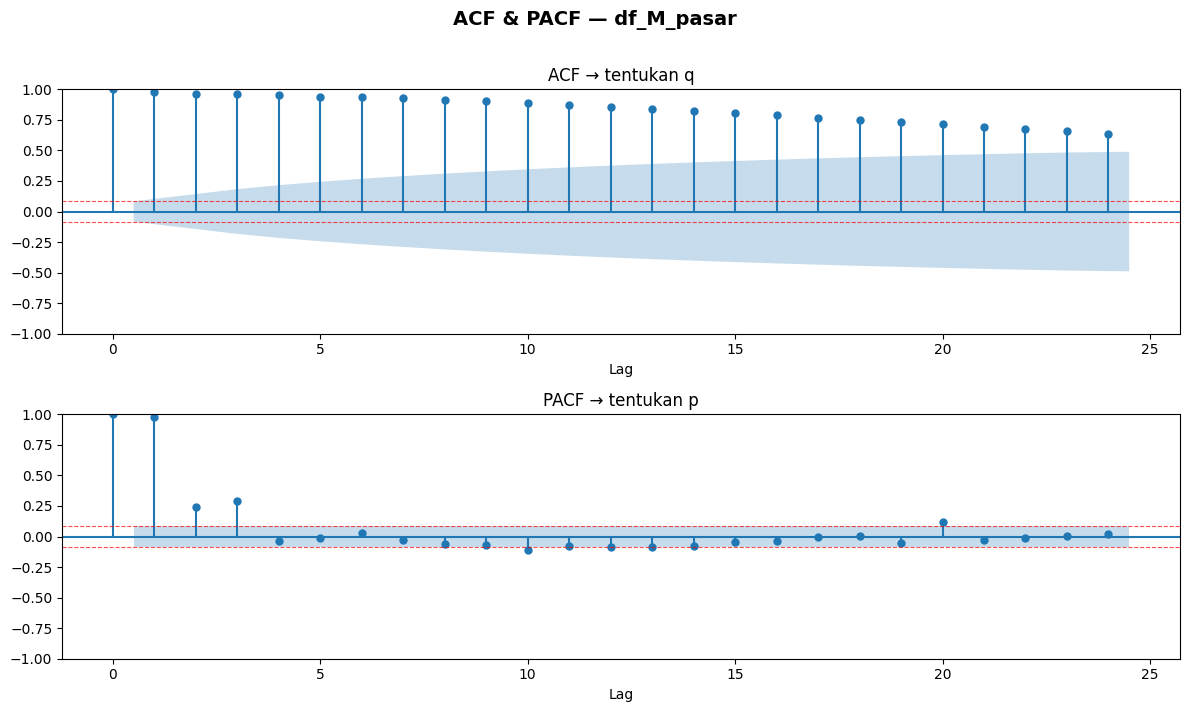


  3. LJUNG-BOX TEST — White Noise Residual: df_M_pasar

  Lag diuji  : 24
  LB Stat    : 9427.1163
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_M_pasar

  ARCH LM Statistic : 144.2005
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


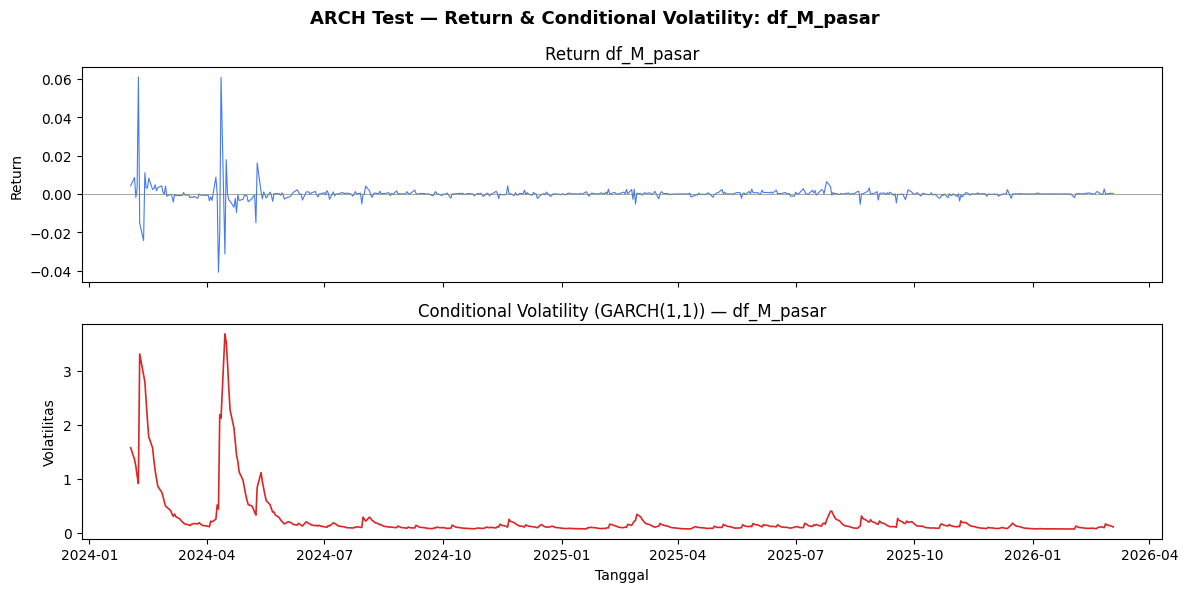


  RINGKASAN HASIL UJI STATISTIK — df_M_pasar
  [ADF (Stasioneritas)]          ✅ Stasioner
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [42]:
series_M, p_kandidat, q_kandidat = jalankan_uji(df_M_pasar, label="df_M_pasar")

## Modeling


████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_M_pasar
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 110
  Rata-rata obs/minggu : 5.0
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 110 obs
  Train      : 88 obs  (2024-02-05 s/d 2025-10-06)
  Test       : 22 obs   (2025-10-13 s/d 2026-03-09)
  d (order)  : 0


  MODEL 1 — ARIMA+GARCH (Grid Search, d=0)
  p kandidat (PACF) : [1, 2, 3]
  q kandidat (ACF)  : [1, 2, 3, 4, 5, 6, 7, 8, 9]
  Hyperparameter tuning : MAE in-sample (bukan AIC)
  Menguji 27 kombinasi ARIMA...

  {'Model':<20} 

02:52:40 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA(3,0,9)(1,0,1,52)                    281.75   456.7183

  🏆 Best SARIMA → order=(1, 0, 2) seasonal=(0, 0, 0, 52)
     MAE_in=185.2702 | AIC=950.17 | BIC=959.94

  ARCH Test pada residual SARIMA:
  LM Stat  : 72.8623
  p-value  : 0.0000
  ❌ Ada efek ARCH → Lanjut fit GARCH(1,1)

  GARCH(1,1) Results:
  AIC   : 1196.01
  BIC   : 1205.92
  omega : 36317.161358
  alpha : 0.0000
  beta  : 0.3324

  Confidence Interval 95%:
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         13074.77     12617.63     13531.90     13075.20
  2         13089.02     12631.89     13546.15     13063.00
  3         13088.25     12631.12     13545.38     12989.40
  4         13087.47     12630.34     13544.60     12947.80
  5         13086.70     12629.57     13543.83     12881.00
  6         13085.92     12628.79     13543.06     12865.20
  7         13085.15     12628.02     13542.28     12868.00
  8         13084.37     12627.

02:52:40 - cmdstanpy - INFO - Chain [1] done processing
02:52:40 - cmdstanpy - INFO - Chain [1] start processing


  1.0      10.0     additive         5             14.7178


...

  0.01     10.0     additive         5             72.4477


02:54:46 - cmdstanpy - INFO - Chain [1] done processing
02:54:47 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3             70.4943

  🏆 Best hyperparameter → CPS=0.05, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=10.6707


02:54:51 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=360.4685  std=16.7993
  • yearly                         mean=2.3562  std=11.4480
  • weekly                         mean=32.1057  std=0.0000
  • custom_period_52               mean=0.0419  std=11.8371

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         13049.72     13014.09     13077.98     13075.20
  2         13067.04     12964.31     13149.69     13063.00
  3         13080.16     12841.40     13278.84     12989.40
  4         13094.38     12675.57     13450.82     12947.80
  5         13190.84     12558.86     13719.01     12881.00
  6         13351.28     12520.73     14090.92     12865.20
  7         13370.25     12341.93     14320.48     12868.00
  8         13349.98     12081.36     14570.53     12856.40
  9         13323.20     11751.08     14797.14     12838.00
  1

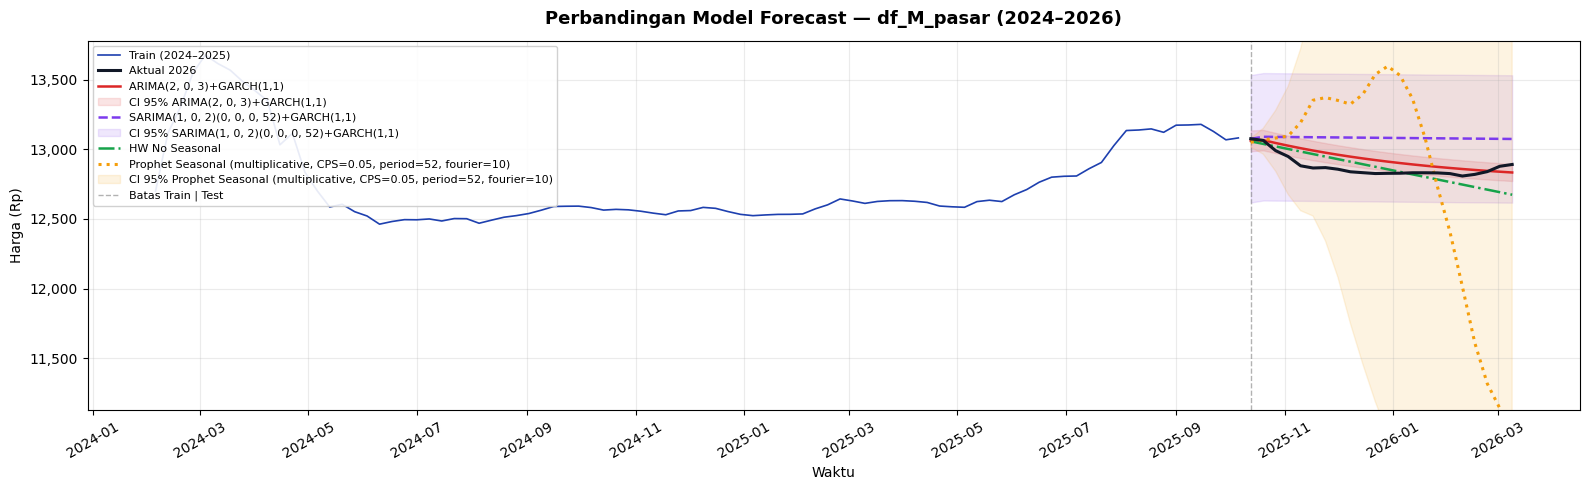


  TABEL PERBANDINGAN MODEL — df_M_pasar — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMA(2, 0, 3)+GARCH(1,1)                    75.394   66.073  0.5138% 🏆
  2    SARIMA(1, 0, 2)(0, 0, 0, 52)+GARCH(1,1)     218.745  206.166  1.6046%
  3    HW No Seasonal                               86.913   69.792  0.5424%
  4    Prophet Seasonal (multiplicative, CPS=0.05, period=52, fourier=10)  813.277  624.666  4.8611%

  🏆 Best Model → ARIMA(2, 0, 3)+GARCH(1,1)


In [43]:
warnings.filterwarnings("ignore")
hasil_M = jalankan_modeling(df_M_pasar, label="df_M_pasar", ke_mingguan=True, include_weekend=False,
                            p_kandidat=p_kandidat, q_kandidat=q_kandidat)

# BERAS PREMIUM PASAR

In [44]:
mask = (df['kode_kab_kota'] == 1) & (df['variant_id'] == 2) & (df['tipe_harga_id'] == 1)
df_P_pasar = df[mask]
df_P_pasar


,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
920,921,1,2026-02-27,2,14664.0,1
921,922,1,2026-03-02,2,14664.0,1
922,923,1,2026-03-03,2,14664.0,1
923,924,1,2026-03-04,2,14656.0,1
239476,242621,1,2024-02-01,2,14289.0,1
...,...,...,...,...,...,...
240630,243775,1,2026-02-20,2,14645.0,1
241204,244534,1,2026-02-23,2,14652.0,1
241205,244535,1,2026-02-24,2,14652.0,1
241476,245575,1,2026-02-25,2,14664.0,1


## Preprocessing

In [45]:
df_P_pasar = search_missing_value(df_P_pasar, week_end=False)

Jumlah data baris = 502
Jumlah missing: 43
Persentase missing: 7.9%
Date missing: [Timestamp('2024-02-14 00:00:00'), Timestamp('2024-03-11 00:00:00'), Timestamp('2024-03-12 00:00:00'), Timestamp('2024-03-29 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-05-23 00:00:00'), Timestamp('2024-05-24 00:00:00'), Timestamp('2024-06-17 00:00:00'), Timestamp('2024-06-18 00:00:00'), Timestamp('2024-07-16 00:00:00'), Timestamp('2024-09-16 00:00:00'), Timestamp('2024-11-27 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-27 00:00:00'), Timestamp('2025-01-28 00:00:00'), Timestamp('2025-01-29 00:00:00'), Timestamp('2025-03-28 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-04-02 00:00:00'), Timestamp('2025-04-03 00:00:00'), Timestamp('2025-04-04 00:00:00'), Timestamp('2025-04-07 00:00:00'), Timestamp('2025-04-18 00:00:00'), Timestamp('2025-05-01 00:00:00'),

In [46]:
df_P_pasar, metrics = evaluate_imputation(df_P_pasar)

Forward Fill
MAE : 21.76923076923077
MAPE: 0.14768954382983157

Linear Interpolation
MAE : 14.596666666666687
MAPE: 0.09912352694092877

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_P_pasar
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_P_pasar
  ADF Statistic : -4.0166
  p-value       : 0.0013
  Lags Used     : 19
  Observations  : 525
  Critical Values:
    1%: -3.4429
    5%: -2.8671
    10%: -2.5697

  ✅ STASIONER (p=0.0013 < 0.05) → Tidak perlu differencing

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_P_pasar

  Batas Signifikansi (±0.0840)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 4, 6]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


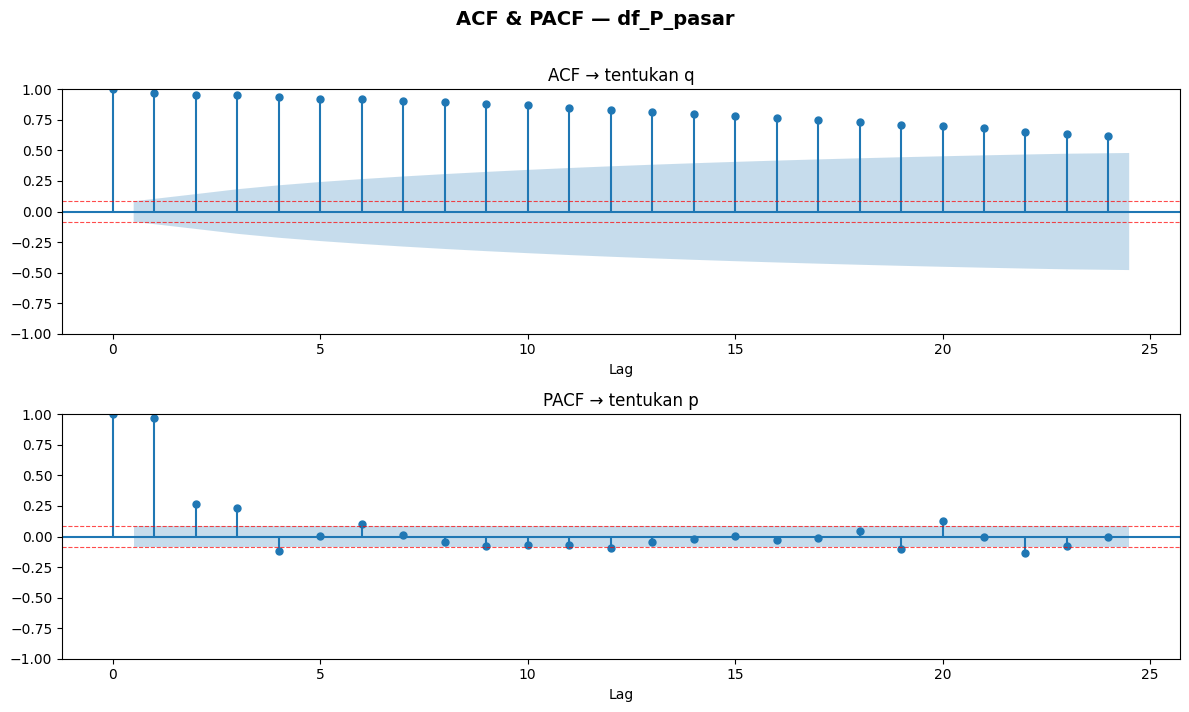


  3. LJUNG-BOX TEST — White Noise Residual: df_P_pasar

  Lag diuji  : 24
  LB Stat    : 9019.4595
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_P_pasar

  ARCH LM Statistic : 179.3959
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


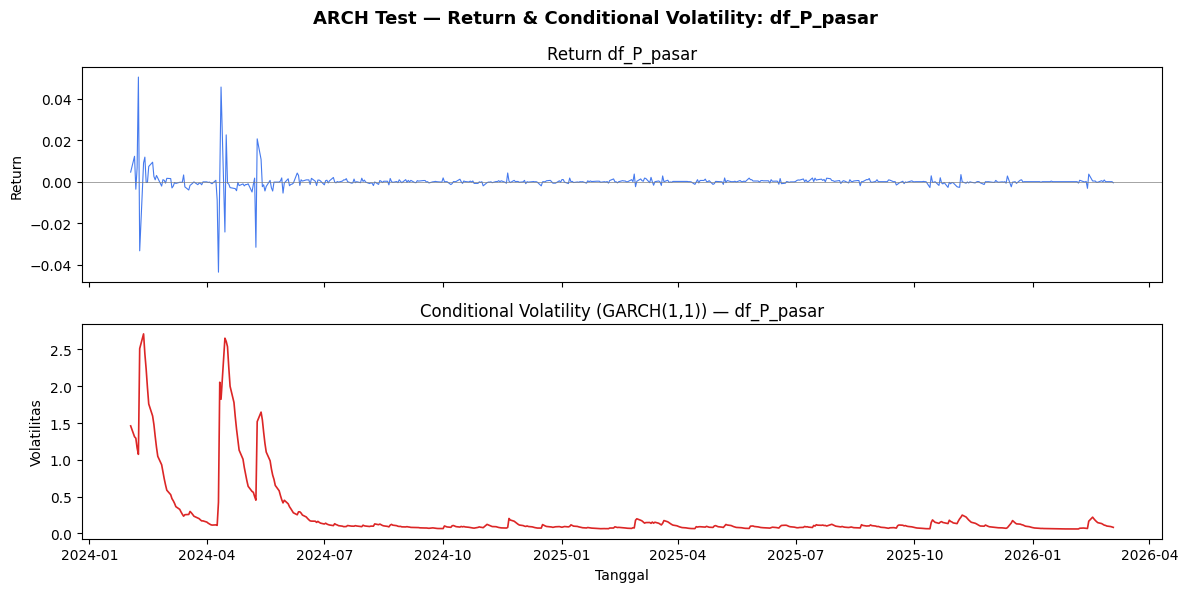


  RINGKASAN HASIL UJI STATISTIK — df_P_pasar
  [ADF (Stasioneritas)]          ✅ Stasioner
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [47]:
series_P, p_kandidat, q_kandidat = jalankan_uji(df_P_pasar, label="df_P_pasar")

## Modeling


████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_P_pasar
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 110
  Rata-rata obs/minggu : 5.0
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 110 obs
  Train      : 88 obs  (2024-02-05 s/d 2025-10-06)
  Test       : 22 obs   (2025-10-13 s/d 2026-03-09)
  d (order)  : 0


  MODEL 1 — ARIMA+GARCH (Grid Search, d=0)
  p kandidat (PACF) : [1, 2, 3, 4, 6, 9]
  q kandidat (ACF)  : [1, 2, 3, 4, 5, 6, 7, 8, 9]
  Hyperparameter tuning : MAE in-sample (bukan AIC)
  Menguji 54 kombinasi ARIMA...

  {'Mod

02:59:27 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA(9,0,1)(1,0,1,52)                    299.59   388.4268

  🏆 Best SARIMA → order=(2, 0, 7) seasonal=(1, 0, 0, 52)
     MAE_in=208.7658 | AIC=320.75 | BIC=337.54

  ARCH Test pada residual SARIMA:
  LM Stat  : 66.1490
  p-value  : 0.0000
  ❌ Ada efek ARCH → Lanjut fit GARCH(1,1)

  GARCH(1,1) Results:
  AIC   : 1220.36
  BIC   : 1230.27
  omega : 46800.093239
  alpha : 0.0000
  beta  : 0.3339

  Confidence Interval 95%:
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         14897.38     14377.83     15416.93     14881.20
  2         14925.48     14405.93     15445.03     14879.00
  3         14943.46     14423.91     15463.01     14855.60
  4         14949.63     14430.08     15469.18     14780.00
  5         14955.41     14435.86     15474.96     14697.40
  6         14967.75     14448.20     15487.30     14686.80
  7         14984.90     14465.36     15504.45     14666.60
  8         15000.80     14481.

02:59:27 - cmdstanpy - INFO - Chain [1] done processing
02:59:27 - cmdstanpy - INFO - Chain [1] start processing


  1.0      10.0     additive         5             17.1295


...

  0.01     10.0     additive         5             75.0808


03:01:30 - cmdstanpy - INFO - Chain [1] done processing
03:01:30 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3             71.5093

  🏆 Best hyperparameter → CPS=0.05, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=14.3896


03:01:33 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=346.8350  std=14.9170
  • yearly                         mean=1.8193  std=8.7535
  • weekly                         mean=37.8193  std=0.0000
  • custom_period_52               mean=0.0930  std=9.0125

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         14788.47     14739.69     14829.14     14881.20
  2         14779.46     14657.65     14875.89     14879.00
  3         14770.27     14494.97     15000.06     14855.60
  4         14797.45     14308.37     15218.58     14780.00
  5         14784.62     14058.51     15396.10     14697.40
  6         14792.47     13839.53     15635.64     14686.80
  7         14660.86     13498.64     15740.26     14666.60
  8         14547.75     13113.72     15912.02     14643.80
  9         14453.76     12695.36     16095.71     14639.40
  10 

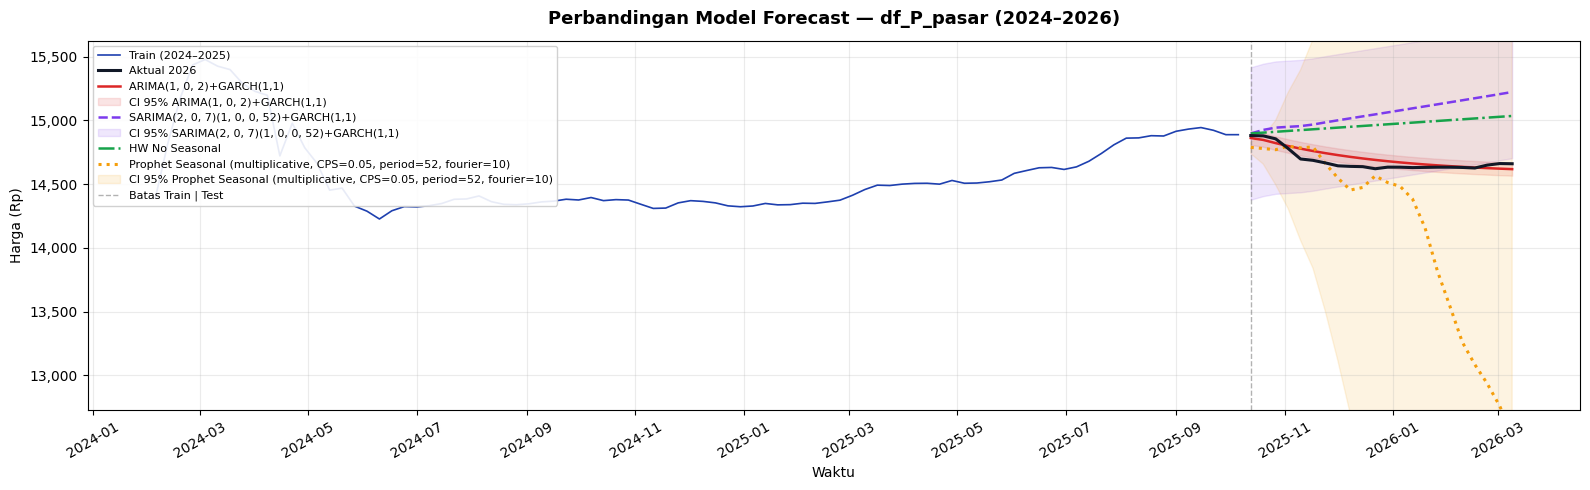


  TABEL PERBANDINGAN MODEL — df_P_pasar — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMA(1, 0, 2)+GARCH(1,1)                    48.440   41.057  0.2798% 🏆
  2    SARIMA(2, 0, 7)(1, 0, 0, 52)+GARCH(1,1)     410.644  376.327  2.5689%
  3    HW No Seasonal                              306.892  284.152  1.9397%
  4    Prophet Seasonal (multiplicative, CPS=0.05, period=52, fourier=10)  895.611  570.618  3.8951%

  🏆 Best Model → ARIMA(1, 0, 2)+GARCH(1,1)


In [48]:
warnings.filterwarnings("ignore")
hasil_P = jalankan_modeling(df_P_pasar, label="df_P_pasar", ke_mingguan=True, include_weekend=False,
                            p_kandidat=p_kandidat, q_kandidat=q_kandidat)

# Beras Medium Konsumen

In [49]:
mask = (
    (df['kode_kab_kota'] == 1) &
    (df['variant_id'] == 1) &
    (df['tipe_harga_id'] == 2) 
)

df_M_Konsum = df[mask]
df_M_Konsum

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
32,33,1,2026-02-27,1,12580.0,2
95,96,1,2026-02-28,1,12634.0,2
156,157,1,2026-03-01,1,12545.0,2
220,221,1,2026-03-02,1,12623.0,2
285,286,1,2026-03-03,1,12623.0,2
...,...,...,...,...,...,...
240731,243876,1,2026-02-22,1,12604.0,2
240795,243940,1,2026-02-23,1,12607.0,2
240861,244006,1,2026-02-24,1,12617.0,2
241239,245338,1,2026-02-25,1,12584.0,2


## Preprocessing

In [50]:
df_M_Konsum = search_missing_value(df_M_Konsum, week_end=True)

Jumlah data baris = 782
Jumlah missing: 12
Persentase missing: 1.5%
Date missing: [Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-23 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-06-11 00:00:00'), Timestamp('2025-06-12 00:00:00'), Timestamp('2025-06-13 00:00:00'), Timestamp('2025-06-14 00:00:00'), Timestamp('2025-06-15 00:00:00'), Timestamp('2026-01-01 00:00:00')]


In [51]:
df_M_Konsum, metrics = evaluate_imputation(df_M_Konsum)

Forward Fill
MAE : 52.68674698795181
MAPE: 0.41776707590971357

Linear Interpolation
MAE : 39.24497991967874
MAPE: 0.31140934203791915

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_M_Konsum
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_M_Konsum
  ADF Statistic : -3.3392
  p-value       : 0.0132
  Lags Used     : 5
  Observations  : 788
  Critical Values:
    1%: -3.4387
    5%: -2.8652
    10%: -2.5687

  ✅ STASIONER (p=0.0132 < 0.05) → Tidak perlu differencing

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_M_Konsum

  Batas Signifikansi (±0.0696)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 6, 11]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


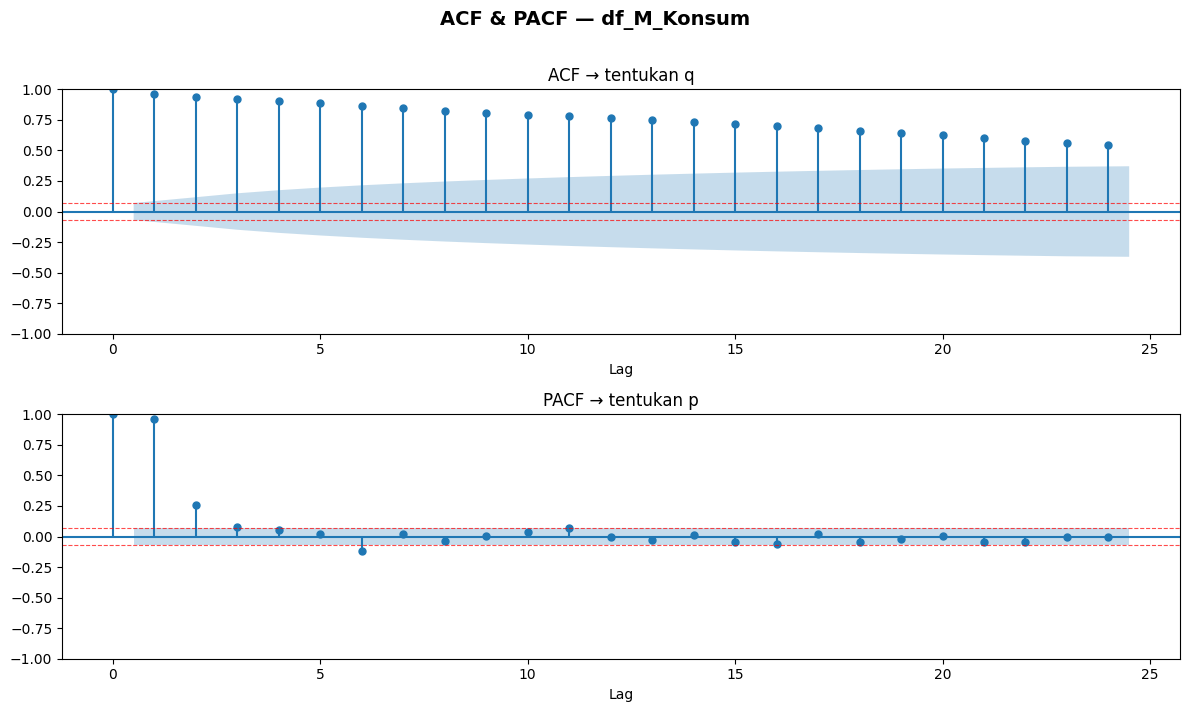


  3. LJUNG-BOX TEST — White Noise Residual: df_M_Konsum

  Lag diuji  : 24
  LB Stat    : 11274.7854
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_M_Konsum

  ARCH LM Statistic : 202.4372
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


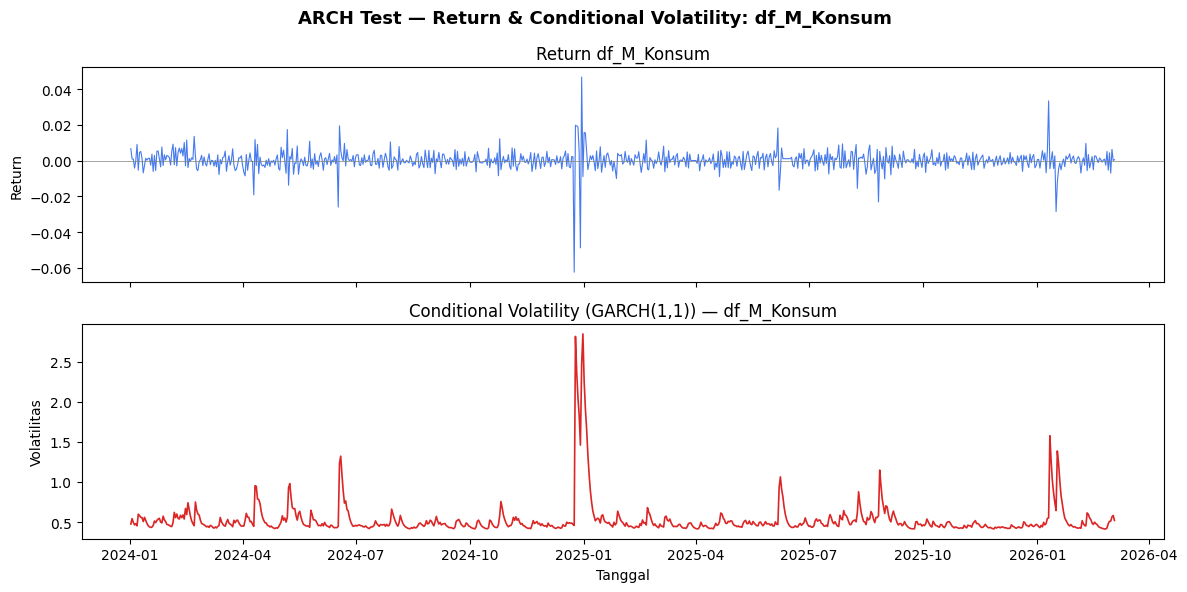


  RINGKASAN HASIL UJI STATISTIK — df_M_Konsum
  [ADF (Stasioneritas)]          ✅ Stasioner
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [52]:
series_P, p_kandidat, q_kandidat = jalankan_uji(df_M_Konsum, label="df_M_Konsum")

## Modeling


  CEK STASIONERITAS & DIFFERENCING — df_M_Konsum

  d=0 | ADF Stat: -3.3392 | p-value: 0.0132  ✅ Stasioner

  Differencing order : d = 0

████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_M_Konsum
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 115
  Rata-rata obs/minggu : 6.9
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 115 obs
  Train      : 92 obs  (2024-01-01 s/d 2025-09-29)
  Test       : 23 obs   (2025-10-06 s/d 2026-03-09)
  d (order)  : 0

  Exog (1 variabel)     : 92 train obs, 23 test obs
  Rentang exog         : 2024-01-01 

03:05:55 - cmdstanpy - INFO - Chain [1] start processing
03:05:55 - cmdstanpy - INFO - Chain [1] done processing


  SARIMAX(6,0,9)(1,0,1,52)                   380.83   188.5045

  🏆 Best SARIMAX → order=(1, 0, 8) seasonal=(1, 0, 1, 52)
     MAE_in=63.3225 | AIC=383.65 | BIC=402.29

  ARCH Test pada residual SARIMAX:
  LM Stat  : 9.5817
  p-value  : 0.6526
  ✅ Tidak ada efek ARCH → GARCH tidak diperlukan

  ──────────────────────────────────────────
  📊 SARIMAX(1, 0, 8)(1, 0, 1, 52) (tanpa GARCH)
  ──────────────────────────────────────────
  RMSE : 102.506
  MAE  : 85.734
  MAPE : 0.6737%

  MODEL 3 — HOLT-WINTERS EXPONENTIAL SMOOTHING
  Hyperparameter tuning : MAE in-sample (bukan AIC)

  Konfigurasi                                    SSE        AIC     MAE_in
  --------------------------------------------------------------------------
  HW Additive                                  GAGAL
  HW Multiplicative                            GAGAL
  HW No Seasonal                          1050385.21     867.54    64.1273
  HW Mul-Trend+Add-Seasonal                    GAGAL

  🏆 Best Holt-Winters → HW No 

03:05:55 - cmdstanpy - INFO - Chain [1] start processing
03:05:55 - cmdstanpy - INFO - Chain [1] done processing
03:05:56 - cmdstanpy - INFO - Chain [1] start processing
03:05:56 - cmdstanpy - INFO - Chain [1] done processing
03:05:56 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.01     multiplicative   5            105.2118
  0.001    0.1      additive         3            106.7597


...

  0.01     10.0     additive         5            102.0055


03:07:42 - cmdstanpy - INFO - Chain [1] done processing
03:07:42 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3            102.9873

  🏆 Best hyperparameter → CPS=1.0, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=16.2774


03:07:44 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=1199.9615  std=80.4934
  • yearly                         mean=-0.6875  std=6.2485
  • weekly                         mean=13.4452  std=0.0000
  • custom_period_52               mean=0.5434  std=6.0189

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         12778.69     12739.81     12820.96     12824.71
  2         12743.32     12649.67     12841.51     12853.00
  3         12646.02     12442.31     12860.50     12844.71
  4         12602.16     12223.79     12960.45     12842.00
  5         12900.13     12328.99     13433.14     12839.00
  6         13446.25     12648.69     14183.51     12829.29
  7         14200.12     13105.21     15177.44     12805.43
  8         15245.99     13774.45     16551.34     12815.43
  9         16278.72     14331.11     17963.25     12791.14
  1

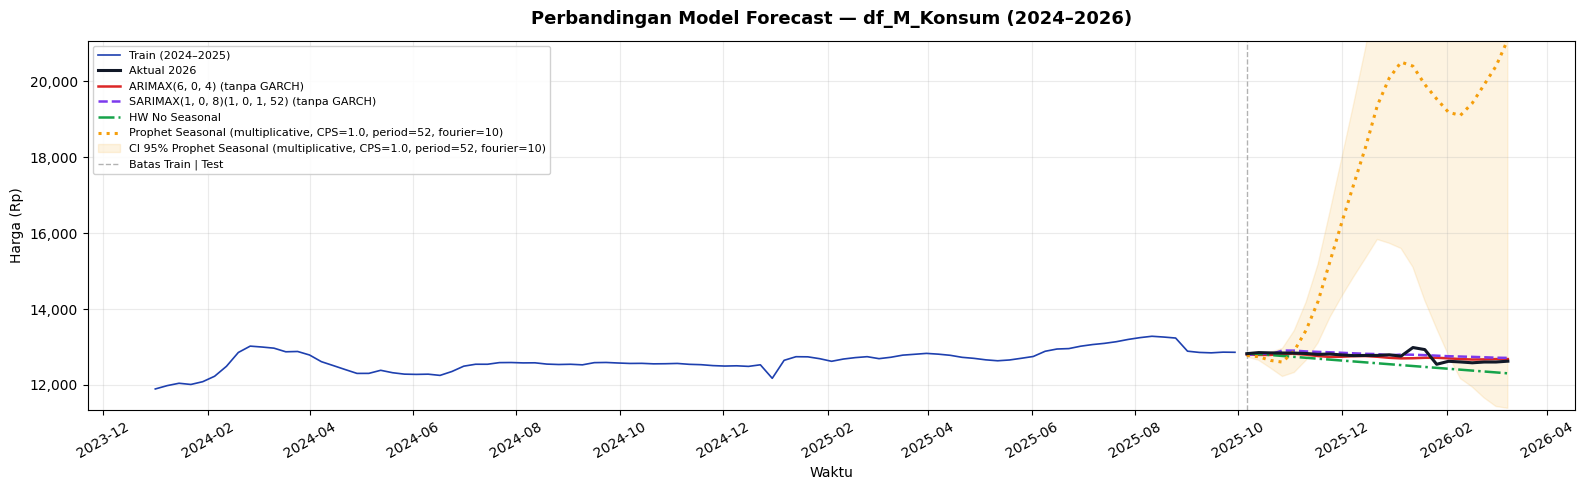


  TABEL PERBANDINGAN MODEL — df_M_Konsum — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMAX(6, 0, 4) (tanpa GARCH)                97.736   73.649  0.5766% 🏆
  2    SARIMAX(1, 0, 8)(1, 0, 1, 52) (tanpa GARCH)  102.506   85.734  0.6737%
  3    HW No Seasonal                              221.288  188.144  1.4742%
  4    Prophet Seasonal (multiplicative, CPS=1.0, period=52, fourier=10) 5511.180 4569.449 35.9291%

  🏆 Best Model → ARIMAX(6, 0, 4) (tanpa GARCH)


In [53]:
warnings.filterwarnings("ignore")
_, d_order = cek_dan_differencing(df_M_Konsum, label="df_M_Konsum")
hasil_P    = jalankan_modeling(df_M_Konsum, label="df_M_Konsum", d_order=d_order,
                                ke_mingguan=True, include_weekend=True,
                                exog_source_df=df_M_pasar,
                                p_kandidat=p_kandidat, q_kandidat=q_kandidat)

# Beras Premium Konsumen

In [54]:
mask = (df['kode_kab_kota'] == 1) & (df['variant_id'] == 2) & (df['tipe_harga_id'] == 2)
df_P_Konsum = df[mask]
df_P_Konsum

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
65,66,1,2026-02-27,2,14803.0,2
127,128,1,2026-02-28,2,14798.0,2
186,187,1,2026-03-01,2,14766.0,2
255,256,1,2026-03-02,2,14779.0,2
316,317,1,2026-03-03,2,14758.0,2
...,...,...,...,...,...,...
240762,243907,1,2026-02-22,2,14783.0,2
240829,243974,1,2026-02-23,2,14783.0,2
240893,244038,1,2026-02-24,2,14818.0,2
241275,245374,1,2026-02-25,2,14810.0,2


## Preprocessing

In [55]:
df_P_Konsum = search_missing_value(df_P_Konsum, week_end=True)

Jumlah data baris = 782
Jumlah missing: 12
Persentase missing: 1.5%
Date missing: [Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-23 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-06-11 00:00:00'), Timestamp('2025-06-12 00:00:00'), Timestamp('2025-06-13 00:00:00'), Timestamp('2025-06-14 00:00:00'), Timestamp('2025-06-15 00:00:00'), Timestamp('2026-01-01 00:00:00')]


In [56]:
df_P_Konsum, metrics = evaluate_imputation(df_P_Konsum)

Forward Fill
MAE : 44.71084337349398
MAPE: 0.3052402704562558

Linear Interpolation
MAE : 37.83132530120482
MAPE: 0.2582293407871003

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_P_Konsum
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_P_Konsum
  ADF Statistic : -4.3560
  p-value       : 0.0004
  Lags Used     : 14
  Observations  : 779
  Critical Values:
    1%: -3.4388
    5%: -2.8653
    10%: -2.5687

  ✅ STASIONER (p=0.0004 < 0.05) → Tidak perlu differencing

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_P_Konsum

  Batas Signifikansi (±0.0696)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 6, 8]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


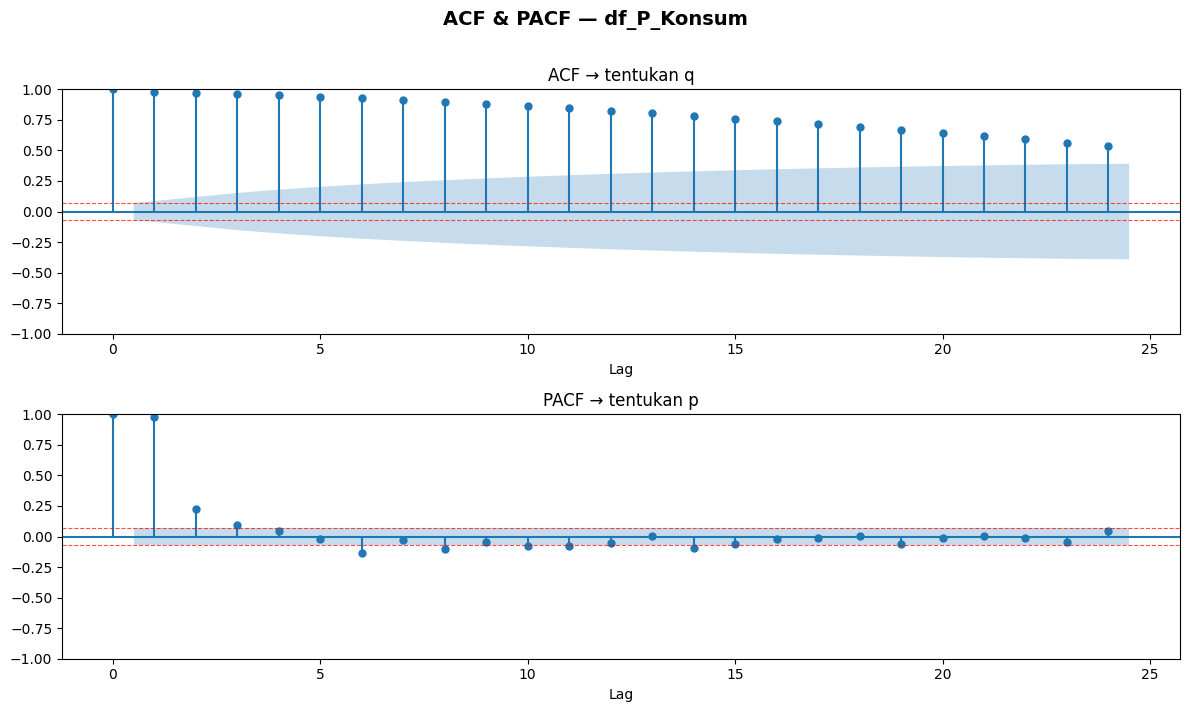


  3. LJUNG-BOX TEST — White Noise Residual: df_P_Konsum

  Lag diuji  : 24
  LB Stat    : 12573.3035
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_P_Konsum

  ARCH LM Statistic : 111.1298
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


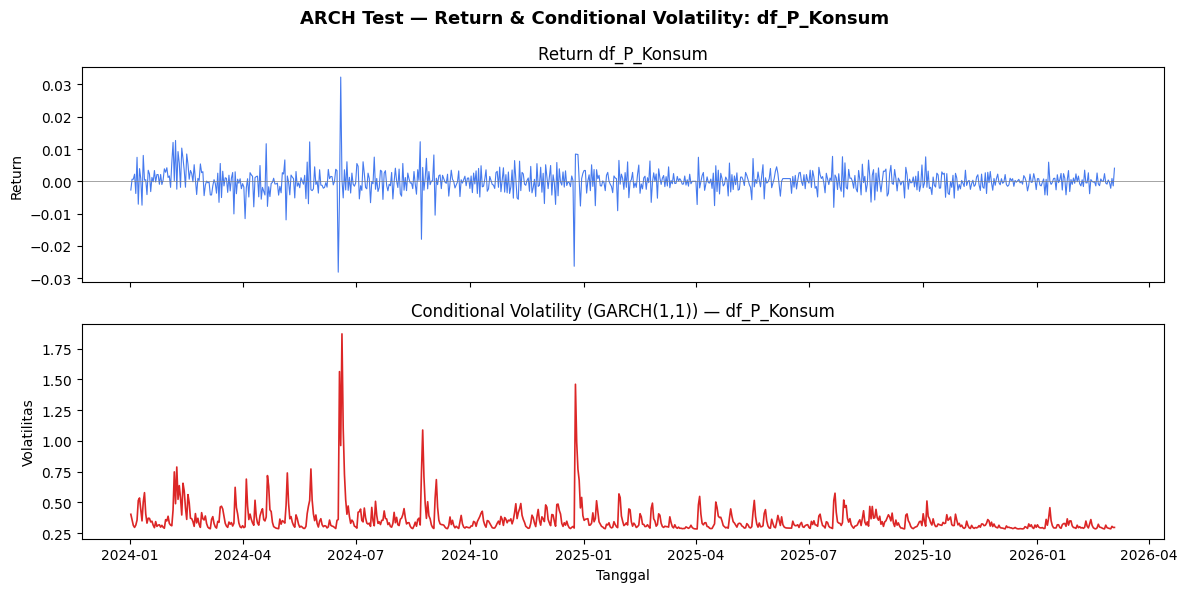


  RINGKASAN HASIL UJI STATISTIK — df_P_Konsum
  [ADF (Stasioneritas)]          ✅ Stasioner
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [57]:
series_P, p_kandidat, q_kandidat = jalankan_uji(df_P_Konsum, label="df_P_Konsum")

## MOdeling


  CEK STASIONERITAS & DIFFERENCING — df_P_Konsum

  d=0 | ADF Stat: -4.3560 | p-value: 0.0004  ✅ Stasioner

  Differencing order : d = 0

████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_P_Konsum
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 115
  Rata-rata obs/minggu : 6.9
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 115 obs
  Train      : 92 obs  (2024-01-01 s/d 2025-09-29)
  Test       : 23 obs   (2025-10-06 s/d 2026-03-09)
  d (order)  : 0

  Exog (1 variabel)     : 92 train obs, 23 test obs
  Rentang exog         : 2024-01-01 

03:12:39 - cmdstanpy - INFO - Chain [1] start processing
03:12:39 - cmdstanpy - INFO - Chain [1] done processing


  SARIMAX(2,0,4)(1,0,1,52)                   370.55    72.9766

  🏆 Best SARIMAX → order=(3, 0, 2) seasonal=(0, 0, 0, 52)
     MAE_in=49.0997 | AIC=1002.49 | BIC=1019.91

  ARCH Test pada residual SARIMAX:
  LM Stat  : 37.6115
  p-value  : 0.0002
  ❌ Ada efek ARCH → Lanjut fit GARCH(1,1)

  GARCH(1,1) Results:
  AIC   : 1009.09
  BIC   : 1019.18
  omega : 34.704129
  alpha : 0.0000
  beta  : 0.9486

  Confidence Interval 95%:
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         15029.46     14973.36     15085.57     15130.86
  2         15015.47     14959.62     15071.32     15087.86
  3         14994.32     14938.72     15049.93     15105.71
  4         14973.52     14918.15     15028.89     14996.43
  5         14953.82     14898.67     15008.98     14912.00
  6         14936.19     14881.25     14991.13     14880.71
  7         14920.79     14866.05     14975.53     14835.14
  8         14907.44     14852.

03:12:39 - cmdstanpy - INFO - Chain [1] start processing


  1.0      10.0     additive         5             14.4513


...

  0.01     10.0     additive         5            141.2165


03:14:51 - cmdstanpy - INFO - Chain [1] done processing
03:14:51 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3            127.4858

  🏆 Best hyperparameter → CPS=0.05, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=9.8060


03:14:54 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=508.1331  std=19.7325
  • yearly                         mean=-4.6182  std=14.5573
  • weekly                         mean=32.1374  std=0.0000
  • custom_period_52               mean=3.5097  std=14.2799

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         15047.41     15022.29     15074.64     15130.86
  2         14988.06     14909.73     15073.29     15087.86
  3         14745.75     14573.52     14926.81     15105.71
  4         14440.48     14118.07     14735.75     14996.43
  5         14304.29     13829.58     14741.05     14912.00
  6         14300.60     13666.00     14888.47     14880.71
  7         14536.07     13695.95     15289.51     14835.14
  8         14914.38     13829.56     15877.37     14804.71
  9         15327.51     13939.08     16527.08     14817.00
  

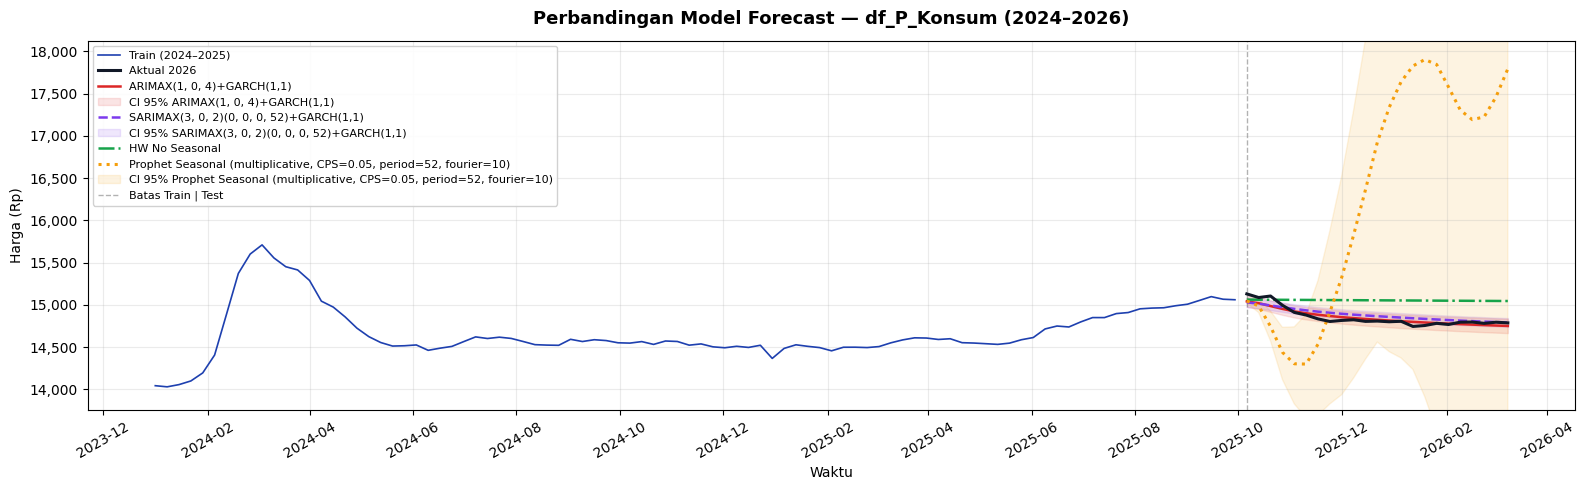


  TABEL PERBANDINGAN MODEL — df_P_Konsum — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMAX(1, 0, 4)+GARCH(1,1)                   45.514   36.296  0.2434% 🏆
  2    SARIMAX(3, 0, 2)(0, 0, 0, 52)+GARCH(1,1)     64.548   56.155  0.3775%
  3    HW No Seasonal                              228.232  213.173  1.4392%
  4    Prophet Seasonal (multiplicative, CPS=0.05, period=52, fourier=10) 2028.545 1667.804 11.2702%

  🏆 Best Model → ARIMAX(1, 0, 4)+GARCH(1,1)


In [58]:
# =====================================================================
# EKSEKUSI
# =====================================================================
_, d_order = cek_dan_differencing(df_P_Konsum, label="df_P_Konsum")
hasil_P    = jalankan_modeling(df_P_Konsum, label="df_P_Konsum", d_order=d_order,
                                ke_mingguan=True, include_weekend=True,
                                exog_source_df=df_P_pasar,
                                p_kandidat=p_kandidat, q_kandidat=q_kandidat)

# Beras Medium Produsen

In [59]:
mask = (df['kode_kab_kota'] == 1) & (df['variant_id'] == 1) & (df['tipe_harga_id'] == 3)
df_M_Produs = df[mask]
df_P_Konsum = df[mask].sort_values(by='tanggal', ascending=True)

df_P_Konsum

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
168672,171817,1,2024-01-01,1,12062.0,3
168709,171854,1,2024-01-02,1,12064.0,3
168750,171895,1,2024-01-03,1,12119.0,3
168796,171941,1,2024-01-04,1,12099.0,3
168841,171986,1,2024-01-05,1,12153.0,3
...,...,...,...,...,...,...
444,445,1,2026-02-28,1,12807.0,3
481,482,1,2026-03-01,1,12800.0,3
525,526,1,2026-03-02,1,12879.0,3
568,569,1,2026-03-03,1,12769.0,3


## Preprocessing

In [60]:
df_M_Produs = search_missing_value(df_M_Produs, week_end=True)

Jumlah data baris = 784
Jumlah missing: 10
Persentase missing: 1.3%
Date missing: [Timestamp('2024-12-24 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2025-06-09 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-06-11 00:00:00'), Timestamp('2025-06-12 00:00:00'), Timestamp('2025-06-13 00:00:00'), Timestamp('2025-06-14 00:00:00'), Timestamp('2026-01-01 00:00:00')]


In [61]:
df_M_Produs, metrics = evaluate_imputation(df_M_Produs)

Forward Fill
MAE : 69.34939759036145
MAPE: 0.5649253704870558

Linear Interpolation
MAE : 59.4839357429719
MAPE: 0.4844907838713358

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_M_Produs
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_M_Produs
  ADF Statistic : -2.3481
  p-value       : 0.1569
  Lags Used     : 18
  Observations  : 775
  Critical Values:
    1%: -3.4388
    5%: -2.8653
    10%: -2.5688

  ❌ TIDAK STASIONER (p=0.1569 ≥ 0.05) → Lakukan differencing (d≥1)

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_M_Produs

  Batas Signifikansi (±0.0696)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 4, 9]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


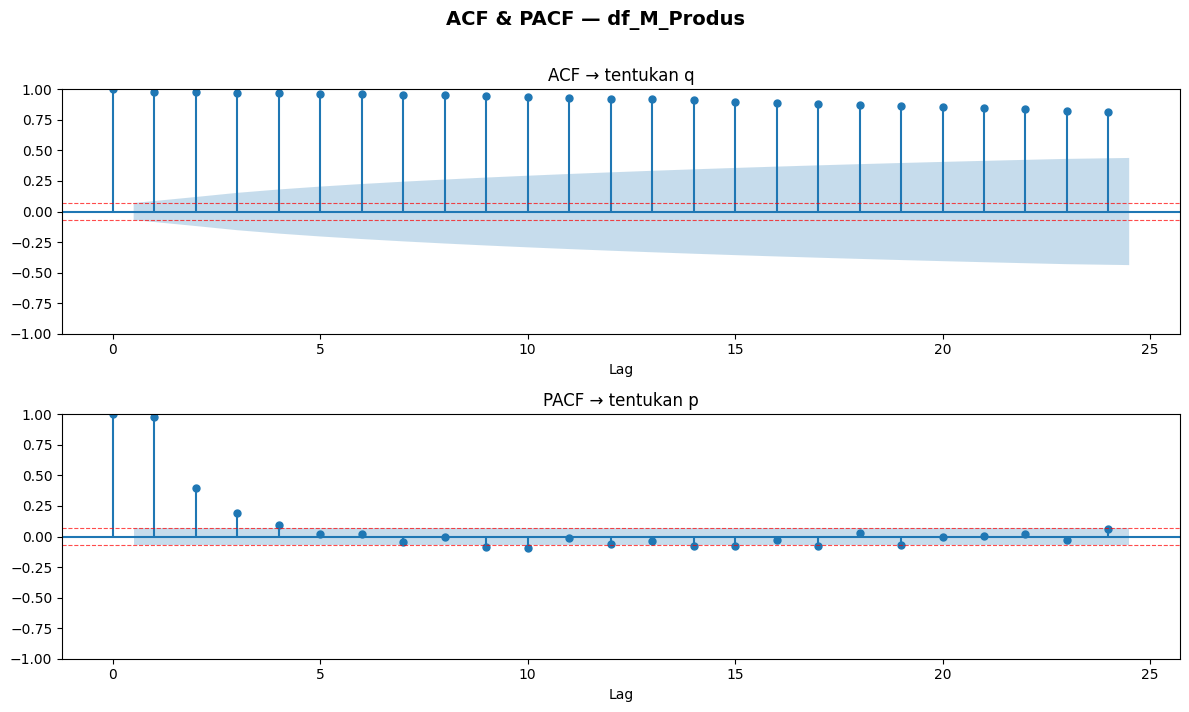


  3. LJUNG-BOX TEST — White Noise Residual: df_M_Produs

  Lag diuji  : 24
  LB Stat    : 16185.5014
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_M_Produs

  ARCH LM Statistic : 185.7548
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


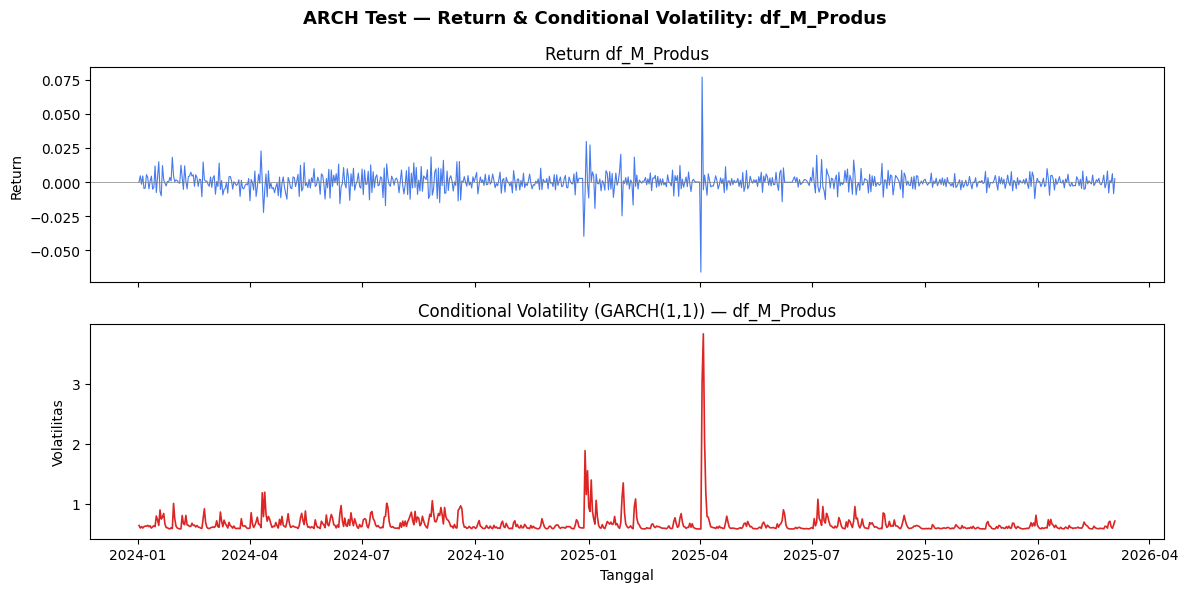


  RINGKASAN HASIL UJI STATISTIK — df_M_Produs
  [ADF (Stasioneritas)]          ❌ Tidak Stasioner → differencing
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Lakukan first-differencing (d=1) sebelum ARIMA
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [62]:
series_P, p_kandidat, q_kandidat = jalankan_uji(df_M_Produs, label="df_M_Produs")

## Modeling


  CEK STASIONERITAS & DIFFERENCING — df_M_Produs

  d=0 | ADF Stat: -2.3481 | p-value: 0.1569  ❌ Tidak Stasioner
  → Melakukan differencing d=1...

  d=1 | ADF Stat: -4.1191 | p-value: 0.0009  ✅ Stasioner

  Differencing order : d = 1

████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_M_Produs
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 115
  Rata-rata obs/minggu : 6.9
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 115 obs
  Train      : 92 obs  (2024-01-01 s/d 2025-09-29)
  Test       : 23 obs   (2025-10-06 s/d 2026-03-09)
  d (ord

03:21:09 - cmdstanpy - INFO - Chain [1] start processing


  SARIMAX(2,1,4)(1,0,1,52)                   140.32     3.7155

  🏆 Best SARIMAX → order=(1, 1, 4) seasonal=(0, 0, 0, 52)
     MAE_in=2.4910 | AIC=690.88 | BIC=710.52

  ARCH Test pada residual SARIMAX:
  LM Stat  : 0.1841
  p-value  : 1.0000
  ✅ Tidak ada efek ARCH → GARCH tidak diperlukan

  ──────────────────────────────────────────
  📊 SARIMAX(1, 1, 4)(0, 0, 0, 52) (tanpa GARCH)
  ──────────────────────────────────────────
  RMSE : 94.885
  MAE  : 76.958
  MAPE : 0.5999%

  MODEL 3 — HOLT-WINTERS EXPONENTIAL SMOOTHING
  Hyperparameter tuning : MAE in-sample (bukan AIC)

  Konfigurasi                                    SSE        AIC     MAE_in
  --------------------------------------------------------------------------
  HW Additive                                  GAGAL
  HW Multiplicative                            GAGAL
  HW No Seasonal                           704558.31     830.81    61.9085
  HW Mul-Trend+Add-Seasonal                    GAGAL

  🏆 Best Holt-Winters → HW No Se

03:21:09 - cmdstanpy - INFO - Chain [1] done processing
03:21:09 - cmdstanpy - INFO - Chain [1] start processing


  1.0      10.0     additive         5             22.1466


...

  0.01     10.0     additive         5            132.9730


03:23:06 - cmdstanpy - INFO - Chain [1] done processing
03:23:06 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3            132.9443

  🏆 Best hyperparameter → CPS=1.0, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=17.7781


03:23:08 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=1150.1397  std=46.2088
  • yearly                         mean=-2.1615  std=6.8472
  • weekly                         mean=11.7625  std=0.0000
  • custom_period_52               mean=1.8715  std=6.9217

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         13070.27     13029.17     13114.72     13078.71
  2         13180.36     13079.63     13288.38     13085.29
  3         13303.77     13078.97     13540.86     13093.14
  4         13179.97     12758.34     13575.75     13033.29
  5         12854.98     12246.89     13422.50     12923.14
  6         12472.85     11678.74     13206.19     12824.29
  7         12226.74     11210.24     13132.26     12789.43
  8         12289.03     11004.86     13427.45     12785.86
  9         12565.54     10930.41     13980.42     12773.71
  1

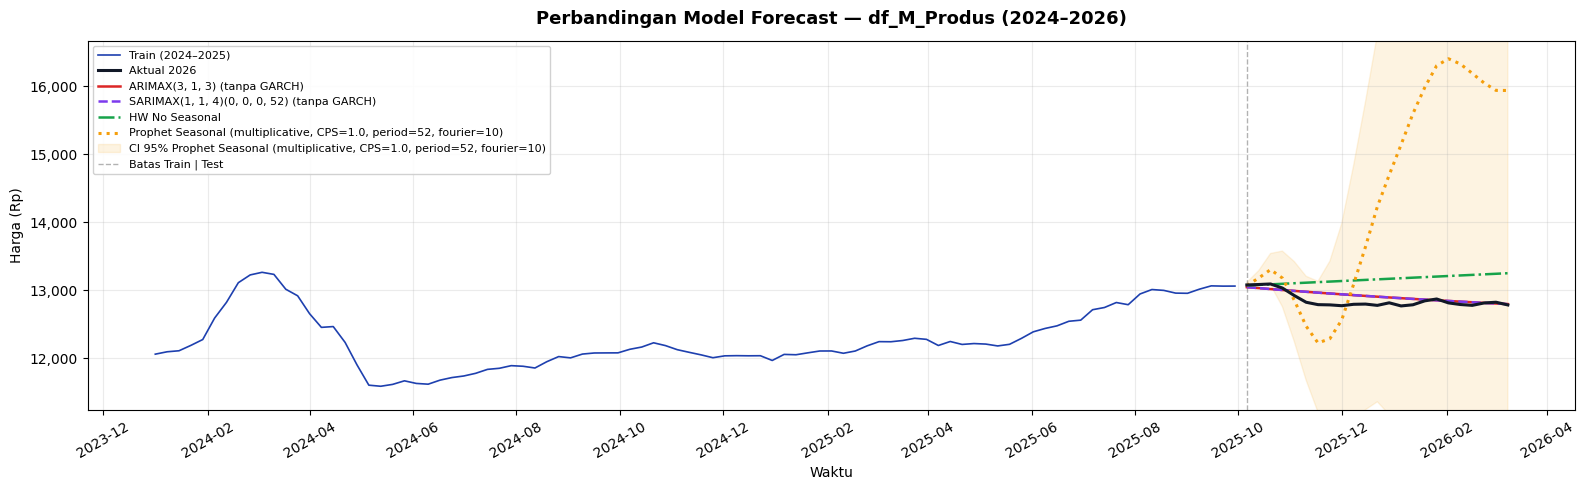


  TABEL PERBANDINGAN MODEL — df_M_Produs — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMAX(3, 1, 3) (tanpa GARCH)                94.919   76.992  0.6002%
  2    SARIMAX(1, 1, 4)(0, 0, 0, 52) (tanpa GARCH)   94.885   76.958  0.5999% 🏆
  3    HW No Seasonal                              340.035  308.030  2.4052%
  4    Prophet Seasonal (multiplicative, CPS=1.0, period=52, fourier=10) 2180.171 1668.289 13.0222%

  🏆 Best Model → SARIMAX(1, 1, 4)(0, 0, 0, 52) (tanpa GARCH)


In [63]:
# =====================================================================
# EKSEKUSI
# =====================================================================
_, d_order = cek_dan_differencing(df_M_Produs, label="df_M_Produs")
hasil_P    = jalankan_modeling(df_M_Produs, label="df_M_Produs", d_order=d_order,
                                exog_source_df=[df_M_pasar, df_P_Konsum],
                                ke_mingguan=True, include_weekend=True,
                                p_kandidat=p_kandidat, q_kandidat=q_kandidat)

# Beras Premium Produsen

In [64]:
mask = (df['kode_kab_kota'] == 1) & (df['variant_id'] == 2) & (df['tipe_harga_id'] == 3)
df_P_Produs = df[mask]
df_P_Produs

,id,kode_kab_kota,tanggal,variant_id,harga,tipe_harga_id
424,425,1,2026-02-27,2,14227.0,3
456,457,1,2026-02-28,2,14259.0,3
498,499,1,2026-03-01,2,14271.0,3
543,544,1,2026-03-02,2,14274.0,3
583,584,1,2026-03-03,2,14251.0,3
...,...,...,...,...,...,...
240973,244188,1,2026-02-22,2,14301.0,3
241013,244228,1,2026-02-23,2,14230.0,3
241055,244270,1,2026-02-24,2,14264.0,3
241364,245463,1,2026-02-25,2,14199.0,3


## Preprocessing

In [65]:
df_P_Produs = search_missing_value(df_P_Produs, week_end=True)

Jumlah data baris = 781
Jumlah missing: 13
Persentase missing: 1.6%
Date missing: [Timestamp('2024-04-10 00:00:00'), Timestamp('2024-04-11 00:00:00'), Timestamp('2024-12-24 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2024-12-26 00:00:00'), Timestamp('2024-12-28 00:00:00'), Timestamp('2025-06-09 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-06-11 00:00:00'), Timestamp('2025-06-12 00:00:00'), Timestamp('2025-06-13 00:00:00'), Timestamp('2025-06-14 00:00:00'), Timestamp('2026-01-01 00:00:00')]


In [66]:
df_P_Produs, metrics = evaluate_imputation(df_P_Produs)

Forward Fill
MAE : 64.3048780487805
MAPE: 0.47360497224577475

Linear Interpolation
MAE : 58.45934959349595
MAPE: 0.42872965307938943

Metode terbaik berdasarkan MAE: linear
Jumlah missing setelah imputasi = 0


## Uji Asumsi


████████████████████████████████████████████████████████████
  ANALISIS STATISTIK — df_P_Produs
████████████████████████████████████████████████████████████

  1. ADF TEST — Stasioneritas: df_P_Produs
  ADF Statistic : -1.5170
  p-value       : 0.5251
  Lags Used     : 6
  Observations  : 787
  Critical Values:
    1%: -3.4387
    5%: -2.8652
    10%: -2.5687

  ❌ TIDAK STASIONER (p=0.5251 ≥ 0.05) → Lakukan differencing (d≥1)

  2. ACF & PACF — Parameter ARIMA (p, d, q): df_P_Produs

  Batas Signifikansi (±0.0696)
  → ACF signifikan pada lag  : [1, 2, 3, 4, 5]  → q kandidat
  → PACF signifikan pada lag : [1, 2, 3, 4, 5]  → p kandidat

  Saran q (MA) : 1
  Saran p (AR) : 1


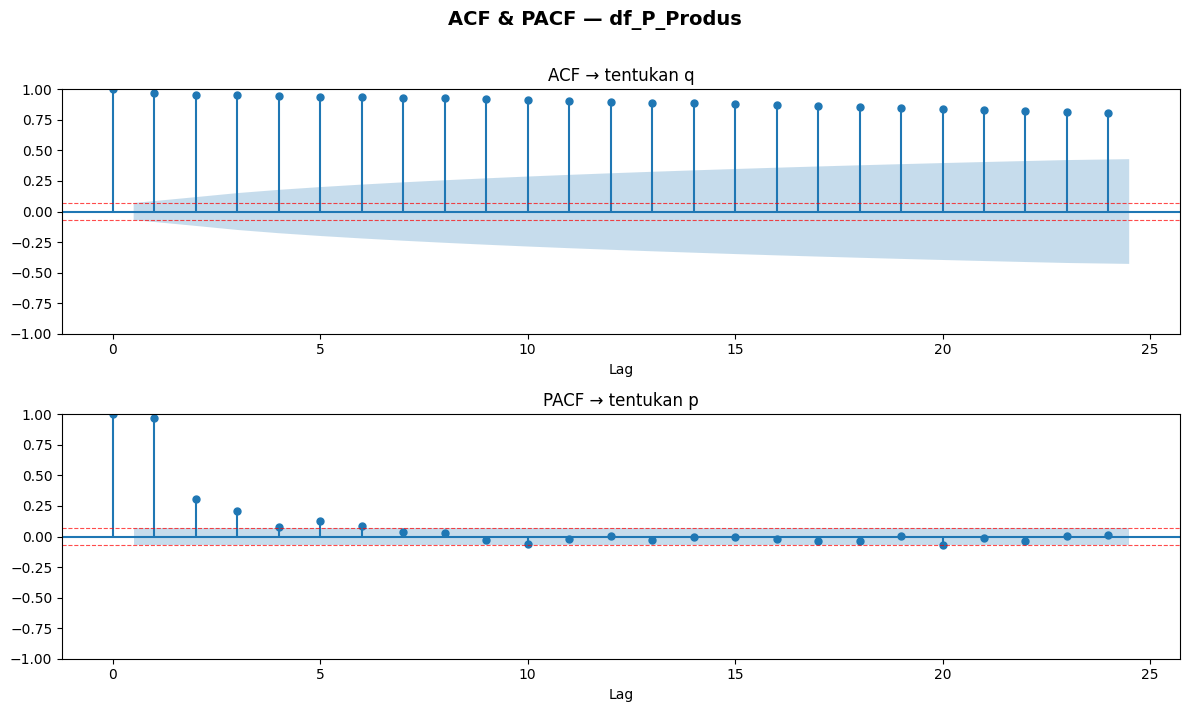


  3. LJUNG-BOX TEST — White Noise Residual: df_P_Produs

  Lag diuji  : 24
  LB Stat    : 15463.5589
  LB p-value : 0.0000

  ❌ Autokorelasi (p=0.0000 < 0.05) — Perlu perbaikan model

  4. ARCH TEST — Heteroskedastisitas & Volatilitas: df_P_Produs

  ARCH LM Statistic : 244.9848
  p-value           : 0.0000
  Lags Diuji        : 12

  ❌ EFEK ARCH ADA (p=0.0000 < 0.05) → Gunakan GARCH


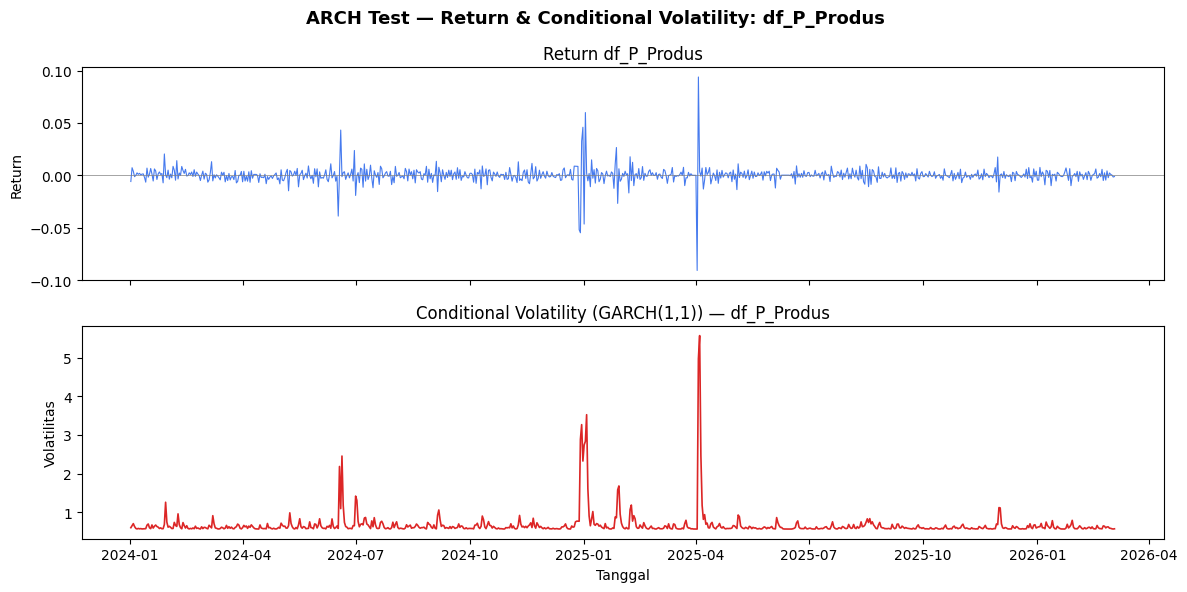


  RINGKASAN HASIL UJI STATISTIK — df_P_Produs
  [ADF (Stasioneritas)]          ❌ Tidak Stasioner → differencing
  [ACF/PACF (ARIMA)]             ✅ Lihat plot untuk p & q
  [Ljung-Box (White Noise)]      ❌ 24 lag signifikan
  [ARCH (Volatilitas)]           ❌ Ada efek ARCH → GARCH

  Rekomendasi:
  • Lakukan first-differencing (d=1) sebelum ARIMA
  • Sesuaikan parameter p, q berdasarkan ACF/PACF
  • Pertimbangkan model GARCH(1,1) untuk volatilitas


In [67]:
series_P, p_kandidat, q_kandidat = jalankan_uji(df_P_Produs, label="df_P_Produs")

## Modeling


  CEK STASIONERITAS & DIFFERENCING — df_P_Produs

  d=0 | ADF Stat: -1.5170 | p-value: 0.5251  ❌ Tidak Stasioner
  → Melakukan differencing d=1...

  d=1 | ADF Stat: -16.6866 | p-value: 0.0000  ✅ Stasioner

  Differencing order : d = 1

████████████████████████████████████████████████████████████
  PEMODELAN FORECAST — df_P_Produs
  Hyperparameter tuning : MAE in-sample
  Pemilihan best model  : MAE out-of-sample
████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────
  🗓️  KONVERSI HARIAN → MINGGUAN
  ────────────────────────────────────────────────────────
  Rule resample        : W-MON  (week_start=Mon)
  Agregasi             : mean
  Jumlah minggu        : 115
  Rata-rata obs/minggu : 6.9
  seasonal_period      : 52 (mingguan)
  ────────────────────────────────────────────────────────

  Total data : 115 obs
  Train      : 92 obs  (2024-01-01 s/d 2025-09-29)
  Test       : 23 obs   (2025-10-06 s/d 2026-03-09)
  d (or

03:28:18 - cmdstanpy - INFO - Chain [1] start processing
03:28:18 - cmdstanpy - INFO - Chain [1] done processing
03:28:19 - cmdstanpy - INFO - Chain [1] start processing


  SARIMAX(6,1,1)(1,0,1,52)                   351.74    98.3348

  🏆 Best SARIMAX → order=(1, 1, 7) seasonal=(0, 0, 1, 52)
     MAE_in=45.8219 | AIC=337.87 | BIC=355.07

  ARCH Test pada residual SARIMAX:
  LM Stat  : 6.6036
  p-value  : 0.8827
  ✅ Tidak ada efek ARCH → GARCH tidak diperlukan

  ──────────────────────────────────────────
  📊 SARIMAX(1, 1, 7)(0, 0, 1, 52) (tanpa GARCH)
  ──────────────────────────────────────────
  RMSE : 57.052
  MAE  : 47.189
  MAPE : 0.3293%

  MODEL 3 — HOLT-WINTERS EXPONENTIAL SMOOTHING
  Hyperparameter tuning : MAE in-sample (bukan AIC)

  Konfigurasi                                    SSE        AIC     MAE_in
  --------------------------------------------------------------------------
  HW Additive                                  GAGAL
  HW Multiplicative                            GAGAL
  HW No Seasonal                           579146.04     812.77    60.7487
  HW Mul-Trend+Add-Seasonal                    GAGAL

  🏆 Best Holt-Winters → HW No S

03:28:19 - cmdstanpy - INFO - Chain [1] done processing
03:28:19 - cmdstanpy - INFO - Chain [1] start processing
03:28:19 - cmdstanpy - INFO - Chain [1] done processing
03:28:19 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.01     multiplicative   5            113.6826
  0.001    0.1      additive         3            198.8723


...

  0.01     10.0     additive         5            108.0181


03:30:16 - cmdstanpy - INFO - Chain [1] done processing
03:30:16 - cmdstanpy - INFO - Chain [1] start processing


  0.01     0.1      multiplicative   3            107.9328

  🏆 Best hyperparameter → CPS=0.3, SPS=10.0, mode=multiplicative, fourier=10
     MAE_in=11.9097


03:30:19 - cmdstanpy - INFO - Chain [1] done processing



  Komponen yang dimodelkan Prophet:
  • trend                          mean=1025.5197  std=80.7954
  • yearly                         mean=-3.4400  std=9.9246
  • weekly                         mean=17.5863  std=0.0000
  • custom_period_52               mean=1.9271  std=9.9128

  Confidence Interval 95% (Prophet uncertainty interval):
  t         Forecast        Lower        Upper       Aktual
  --------------------------------------------------------
  1         14280.44     14250.67     14312.25     14495.29
  2         14066.01     13980.63     14157.26     14521.43
  3         13739.21     13554.81     13933.61     14477.71
  4         13417.99     13077.63     13730.09     14455.29
  5         13353.98     12855.79     13815.55     14388.00
  6         13503.03     12831.17     14125.70     14297.57
  7         13817.08     12925.93     14614.28     14268.29
  8         14458.59     13293.36     15493.06     14270.14
  9         15267.53     13745.12     16583.50     14298.86
  1

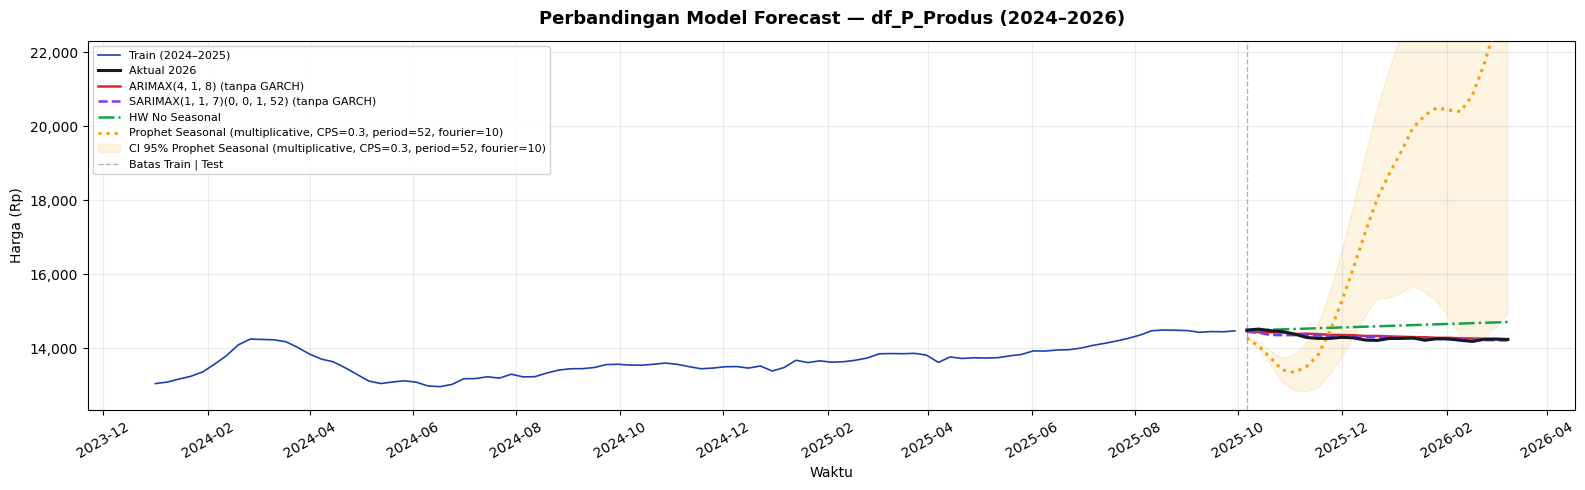


  TABEL PERBANDINGAN MODEL — df_P_Produs — Test 2026
  Kriteria pemilihan best model : MAE terkecil
  No   Model                                          RMSE      MAE     MAPE
  ------------------------------------------------------------------------
  1    ARIMAX(4, 1, 8) (tanpa GARCH)                67.083   55.675  0.3897%
  2    SARIMAX(1, 1, 7)(0, 0, 1, 52) (tanpa GARCH)   57.052   47.189  0.3293% 🏆
  3    HW No Seasonal                              335.512  300.984  2.1114%
  4    Prophet Seasonal (multiplicative, CPS=0.3, period=52, fourier=10) 4779.686 3763.832 26.4082%

  🏆 Best Model → SARIMAX(1, 1, 7)(0, 0, 1, 52) (tanpa GARCH)


In [68]:
# =====================================================================
# EKSEKUSI
# =====================================================================
_, d_order = cek_dan_differencing(df_P_Produs, label="df_P_Produs")
hasil_P    = jalankan_modeling(df_P_Produs, label="df_P_Produs", d_order=d_order,
                                ke_mingguan=True, include_weekend=True,
                                exog_source_df=[df_M_pasar, df_P_Konsum],
                                p_kandidat=p_kandidat, q_kandidat=q_kandidat)